In [739]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import xarray as xr

graphs_path = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/graphs_jupyter_notebook"

## Helper Functions

In [741]:
class SolarField:
    def __init__(self, location, tilt, azimuth, module_capacity, module_area, field_capacity, temp_co, efficiency):
        """
        Initialize a SolarField object with key properties.

        :param location: tuple(float,float) - (lat,lon), latitude (North positive, South negative), longitude (East positive, West negative) 
        :param tilt: float - Tilt angle of the solar panels in degrees
        :param azimuth: float - Orientation of the panels (0° = North, 180° = South)
        :param module_capacity: list of float - Maximum power out capacity of the solar module in MW
        :param module_area: float - Surface area of the solar module in square meters
        :param field_area: float - Total surface area of the solar field in square meters
        :param field_capacity: float - Total capacity of the solar field in MW(DC)
        :param temp_co: float - Temperature Coefficient for the  module installed as given in data sheet. normalized [0,1] scale
        :param efficiency: float - Efficiency of the module, % power out for watt of irradiance as given in data sheet. normalizd [0,1] scale
        """
        self.location = location
        self.tilt = tilt
        self.azimuth = azimuth
        self.module_capacity = module_capacity
        self.module_area = module_area
        self.field_capacity = field_capacity
        self.temp_co = temp_co
        self.efficiency = efficiency

    def get_info(self):
        """
        Returns a dictionary with all solar field properties.
        """
        return {
            "Location": self.location,
            "Tilt (°)": self.tilt,
            "Azimuth (°)": self.azimuth,
            "Module Capacity (MW)": self.module_capacity,
            "Module Area (m²)": self.module_area,
            "Field Capacity (MW)": self.field_capacity,
            "Temperature Coefficient (percent)": self.temp_co,
            "Efficiency": self.efficiency

        }

    def __str__(self):
        """
        Returns a formatted string representation of the solar field.
        """
        return (f"Solar Field at {self.location}:\n"
                f" - Tilt Angle: {self.tilt}°\n"
                f" - Azimuth: {self.azimuth}°\n"
                f" - Module Capacity: {self.module_capacity} MW\n"
                f" - Module Area: {self.module_area} m²\n"
                f" - Field Capacity: {self.field_capacity} MW\n"
                f" - Temperature Coefficient: {self.temp_co}\n"
                f" - Efficiency: {self.efficiency}")

# Example usage
solar_field = SolarField(location=(40.2, -74.6), tilt=30, azimuth=180, module_capacity=[0.5,0.3], module_area=1, field_capacity = 500,  temp_co = 0.36, efficiency = 0.2)
print(solar_field)  # Print object details
print(solar_field.get_info())  # Get properties as a dictionary


##populate 
#### populating all sola fields and their modules data
WWS002 = SolarField(location=(40.331650, -74.643495), tilt=12, azimuth=226, module_capacity=[380/1e6], module_area=2, field_capacity = 15552*380/1e6,  temp_co = 0.36/100, efficiency = 18.94/100)
WWS003 = SolarField(location=(40.335473, -74.636210), tilt=12, azimuth=226, module_capacity=[380/1e6], module_area=2, field_capacity = 8316*380/1e6, temp_co = 0.36/100, efficiency = 18.94/100)
# PRS003 AKA West Garage. has both tilt of 7 and 3. right not for simplicity took only tilt = 7. 
PRS003 = SolarField(location=(40.341127, -74.658015), tilt=7, azimuth=160, module_capacity= [385/1e6, 395/1e6], module_area=2, field_capacity = .83, temp_co = 0.37/100, efficiency = 19.3/100)
# PRS005 AKA Lot20/23, visitor parking 
PRS005 = SolarField(location=(40.340567, -74.657224), tilt=3, azimuth=110, module_capacity= [385/1e6, 395/1e6], module_area=2, field_capacity =2.348, temp_co = 0.37/100, efficiency = 19.3/100)

'''
WWS002:
15,552 panels rated at 380W
WWS003
8,316 panels rated at 380W
PRS003
2144 panels: 1504 rated at 385W, 640 rated at 395W 
PRS005
6032 panels: 3,406 rated at 385W, 2,626 rated at 395W 
'''

Solar Field at (40.2, -74.6):
 - Tilt Angle: 30°
 - Azimuth: 180°
 - Module Capacity: [0.5, 0.3] MW
 - Module Area: 1 m²
 - Field Capacity: 500 MW
 - Temperature Coefficient: 0.36
 - Efficiency: 0.2
{'Location': (40.2, -74.6), 'Tilt (°)': 30, 'Azimuth (°)': 180, 'Module Capacity (MW)': [0.5, 0.3], 'Module Area (m²)': 1, 'Field Capacity (MW)': 500, 'Temperature Coefficient (percent)': 0.36, 'Efficiency': 0.2}


'\nWWS002:\n15,552 panels rated at 380W\nWWS003\n8,316 panels rated at 380W\nPRS003\n2144 panels: 1504 rated at 385W, 640 rated at 395W \nPRS005\n6032 panels: 3,406 rated at 385W, 2,626 rated at 395W \n'

In [742]:
def deg_f_to_c(degrees_f: float) -> float:
    c = (degrees_f - 32)*5/9
    return c 

In [743]:
def pad_empty_dates(df: pd.DataFrame) -> pd.DataFrame:
    '''
    :param: df - a datetime indexed df with "holes" in data capture dates
    return: df with addition of the un-collected dates as NaN values. Will allow to plot data showing a gap when no data was collected.
    '''
    # Ensure index is in datetime format 
    df.index = pd.to_datetime(df.index)
    
    # round down minute format by 10min. make sure all on field logs have same minute format. 
    df.index = df.index.map(lambda x: x - pd.Timedelta(minutes = x.minute % 10, seconds = x.second, microseconds = x.microsecond))

    # Define full date range
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="10min")  # 10-minute intervals

    # Reindex to introduce missing timestamps
    df = df.reindex(full_range)

    return df
    

In [744]:
def merge_real_and_modeled_p(df_real: pd.DataFrame, t_index1: int, p_index1: int, 
                      df_model: pd.DataFrame, t_index2: int, p_index2: int):
    '''
    merge a real power out with a nodeled powre out dataframe 
    '''
    
    df_model.loc[:, "datehour"] = df_model.iloc[:, t_index2].dt.strftime("%Y-%m-%d %H:00")
    df_real.loc[:, "datehour"] = df_real.iloc[:, t_index1].dt.strftime("%Y-%m-%d %H:00")

    # Merge real and modeled power data on 'datehour'
    real_and_modeled_power = df_model.merge(df_real, on="datehour", how="left")

    return real_and_modeled_power


In [745]:
def plot_real_model_p2(df_real: pd.DataFrame, t_index1: int, p_index1: int, 
                      df_model: pd.DataFrame, t_index2: int, p_index2: int, 
                      title: str):
    """
    Plots real and modeled power output.
    
    :param df_real: pd.DataFrame - Real power dataframe.
    :param t_index1: int - Index of real power dataframe with time data.
    :param p_index1: int - Index of real power dataframe with power data.
    :param df_model: pd.DataFrame - Modeled power dataframe.
    :param t_index2: int - Index of modeled power dataframe with time data.
    :param p_index2: int - Index of modeled power dataframe with power data.
    :param title: str - Title of the plot.
    
    :return: real_and_modeled_power dataframe
    """

    '''
    # Convert time columns to datetime strings (hourly format)
    df_model.loc[:, "datehour"] = df_model.iloc[:, t_index2].dt.strftime("%Y-%m-%d %H:00")
    df_real.loc[:, "datehour"] = df_real.iloc[:, t_index1].dt.strftime("%Y-%m-%d %H:00")

    # Merge real and modeled power data on 'datehour'
    real_and_modeled_power = df_model.merge(df_real, on="datehour", how="left")

    '''
    real_and_modeled_power = merge_real_and_modeled_p(df_real, t_index1, p_index1, df_model, t_index2, p_index2)
    real_power_col_name = df_real.columns[p_index1]


    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot modeled power
    ax.plot(real_and_modeled_power.iloc[:, 0], real_and_modeled_power.iloc[:, p_index2], 
            linestyle='-', color='b', label='Model Power Output (kW)')

    # Plot real power
    ax.plot(real_and_modeled_power.iloc[:, 0], real_and_modeled_power[real_power_col_name], 
            linestyle='-', color='r', alpha=0.7, label='Real Power Output (kW)')

    # Formatting
    ax.set_xlabel('Datetime')
    ax.set_ylabel('Power Output (kW)')
    ax.set_title(title)

    # Format x-axis to show a specific time interval
    # option 1
    #plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))  # Show every 6 hours
    #plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

    # option 2
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))


    # Rotate x-axis labels
    plt.xticks(rotation=45)

    # Add grid and legend
    ax.grid(True)
    ax.legend()

    # Adjust layout
    plt.tight_layout()

    # Return figure and axis for further modifications
    return real_and_modeled_power


In [746]:
def clean_SOLPOS_xl(path: str) -> pd.DataFrame:
    """
    takes a SOLPOS NREL file and returns a parsed dataframe
    """
    df_irradiance = pd.read_excel(path) 
    # parse data to separate columns
    df_irradiance = df_irradiance.iloc[:,0].str.split(',', expand = True)
    # parse datetime values
    df_irradiance["Datetime"] = pd.to_datetime(df_irradiance.iloc[:,0] + " " + df_irradiance.iloc[:,1])
    
    df_irradiance["GlobalIrradiance(W/m2)"] = df_irradiance.iloc[:,2]
    
    # Ensure 'AngleOfIncidence' is numeric (converts invalid values to NaN)
    df_irradiance["GlobalIrradiance(W/m2)"] = pd.to_numeric(df_irradiance["GlobalIrradiance(W/m2)"], errors="coerce")
    
    df_irradiance = df_irradiance.iloc[:,-2:]
    return df_irradiance

In [747]:
def clear_days(df: pd.DataFrame, date_index: int) -> pd.DataFrame:
    """
    :param df: pd.DataFrame, data frame to filter clear days from. 
    :param date_index: the index of column in df with dates. 
    inside function param:
    alpha: the upper bound for cloud scatter allowed [0,1]. for clear days <.02 or lower bound is recommended.  
    """
    alpha = .06 # 0 = no clouds. 1 = fully cloudy
    # ensure date series is in datetime format and only day dates. 
    df.loc[:,"date"] = pd.to_datetime(df.iloc[:,date_index]).dt.date
    # left join avg cloud scatter data on days of data frame
    df_tcc_merged = df.merge(AVG_DAILY_TCC_2, on="date", how="left")
   
    # filter clear days, tcc < alpha 
    df_clear_days = df_tcc_merged.loc[df_tcc_merged["tcc"] <= alpha]

    return df_clear_days


In [748]:
def module_power_out_kw_series(module_temp: pd.Series,beam_irradiance: pd.Series, module: SolarField) -> pd.Series:
    """
    the input data is one data frame with the irradiance and temperature dates already joined and synced. 
    :param beam_irradiance: pandas series, clear sky global irradiance from NREL based on angle of incidence of module.
                     Calculations is meant for days with no cloud coverage
    :param module_temp: pandas series, temperature of the solar module on field. 
    :param module: SolarField class containing information about the tachnical specification of modules in a specific solar field. 
    
    return: estimated power out of the solar field in kW based on power modeling function of thesis report.
    """
    # calculate p_out of solar module in W
    module_p_out_w = module.efficiency*beam_irradiance*module.module_area*(1-(module.temp_co*(module_temp-25)*module.efficiency))
    # make sure module p_out is not above the max possible in tech sheet
    for p in module_p_out_w:
        if(p > module.module_capacity[0]*1e6):
            p = module.module_capacity[0]*1e6

    return module_p_out_w
    

In [749]:
def field_power_out_kw_df(module_temp: pd.DataFrame, time_index: int, 
                                          temp_index: int, SOLPOS_data: pd.DataFrame, module: SolarField) -> pd.DataFrame:
    """
    a more general version of field_power_out_kw(). 
    :param module_temp: pandas dataframe - on field data of module surface temperature over time.
    :param time_index: int - the module_temp dataframe column index where time data is.
    :param temp_index: int - the module_temp dataframe column index where temperature is. 
    :param is_BAPI: boolean - taking under account BAPI temperature account that is hourly. 
    :param SOLPOS_data: pd.DataFrame - df with irradiance data for that specific field. Irradiance in ["GlobalIrradiance(W)"] column
    :param module: SolarField class containing information about the technical specification of modules in a specific solar field. 
    return: pd.DataFrame - estimated power out of the solar field in kW based on power modeling function of thesis report. 
    """
    # ensure time indexes are in datetime format 
    #module_temp.iloc[:,time_index] = pd.to_datetime(module_temp.iloc[:,time_index])
    #SOLPOS_data['Datetime'] = pd.to_datetime(SOLPOS_data['Datetime'])
    
    # round down minute to 10. 
    module_temp.iloc[:, time_index] = module_temp.iloc[:, 0].apply(
    lambda x: x - pd.Timedelta(minutes=x.minute % 10, seconds=x.second, microseconds=x.microsecond) 
    if pd.notna(x) else x  # Skip NaN values
    )
    
    #rechange to timestamp inroder to easily merge 
    
    # join irradiance data to module_temp df
    module_temp_with_irr = module_temp.merge(
        SOLPOS_data[['Datetime', 'GlobalIrradiance(W/m2)']],  
        left_on=module_temp.iloc[:,time_index],  
        right_on="Datetime",  
        how="left"
    )
    
    module_temp_with_irr["modeled_p_out_kw"] = field_power_out_kw_series(module_temp_with_irr.iloc[:, temp_index], module_temp_with_irr['GlobalIrradiance(W/m2)'],module)
        
    return module_temp_with_irr


In [750]:
## Populate data into Global Variables (climate data, power data, temperature) 

In [751]:
# real power output data from princeton energy department 
"""
hourly power out for each field. nov 15 - feb 26th 2025 
"""
path_real_power_out = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/power out and temp data from Saurabhi Mishra/Solar Real Power Sum_2025-04-09T10_10_49.xlsx"
df_real_power_out = pd.read_excel(path_real_power_out)

DF_REAL_POWER_WWS002 = df_real_power_out.iloc[:,[0,6]]
DF_REAL_POWER_WWS003 = df_real_power_out.iloc[:,[0,7]]
DF_REAL_POWER_PRS003 = df_real_power_out.iloc[:,[0,9]]
DF_REAL_POWER_PRS005 = df_real_power_out.iloc[:,[0,10]]

real_power_list = [DF_REAL_POWER_WWS002,DF_REAL_POWER_WWS003,DF_REAL_POWER_PRS003,DF_REAL_POWER_PRS005]

# clearing negative values. Negative values exist to show energy needed to warm inverters at night
# taking out NaN values
for df in real_power_list: 
    df.iloc[:, 1] = pd.to_numeric(df.iloc[:, 1], errors='coerce')  # Ensure data is numeric
    df.iloc[:, 1] = np.where(df.iloc[:, 1] < 0, 0, df.iloc[:, 1]) # taking out negative values
    

DF_REAL_POWER_WWS002.index = pd.to_datetime(DF_REAL_POWER_WWS002['Timestamp'])
DF_REAL_POWER_WWS003.index = pd.to_datetime(DF_REAL_POWER_WWS003['Timestamp'])
DF_REAL_POWER_PRS003.index = pd.to_datetime(DF_REAL_POWER_PRS003['Timestamp'])
DF_REAL_POWER_PRS005.index = pd.to_datetime(DF_REAL_POWER_PRS005['Timestamp'])


## Read Climate data

In [753]:
# retreive and read climate data

#from online database "ERA5 hourly data on single levels from 1940 to present" 
grib_path = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/meteo data - ERA5 ACS API requests/16-03-25 temperature query/d6472226722f609252301e393aa421de.grib"

ERA5_CLIMATE_DATA = xr.open_dataset(grib_path)

# filter data for nearet long lat to solar fields if several options come up
#ERA5_temp_2024 = ERA5_temp_2024['t2m'].sel(latitude=40.35, longitude=-74.65, method='nearest')

ERA5_CLIMATE_DATA = ERA5_CLIMATE_DATA.to_dataframe()
ERA5_CLIMATE_DATA['t2m'] =  ERA5_CLIMATE_DATA['t2m'] - 273.15

# set datetime index 
ERA5_CLIMATE_DATA = ERA5_CLIMATE_DATA.reset_index(level=[1, 2])
# Convert timestamp to datetime if needed
ERA5_CLIMATE_DATA.index = pd.to_datetime(ERA5_CLIMATE_DATA.index).round('s')
# adjust time zone from UTC 0 to UTC -5
ERA5_CLIMATE_DATA.index = ERA5_CLIMATE_DATA.index - pd.DateOffset(hours=5)
ERA5_CLIMATE_DATA= ERA5_CLIMATE_DATA.loc[:,['latitude', 'longitude', 't2m', 'tcc']]

AVG_DAILY_TCC = ERA5_CLIMATE_DATA
AVG_DAILY_TCC["date"] = AVG_DAILY_TCC.index
AVG_DAILY_TCC = AVG_DAILY_TCC.groupby("date")["tcc"].mean().reset_index()
AVG_DAILY_TCC.index = pd.to_datetime(AVG_DAILY_TCC['date'])


In [754]:
'''
shortwave radiation data collected in Princeton's Forrestal Campus.
40.345390, -74.617715
Actual horizontal irradiance (actual direct + diffuse) every minute. 

'''
data_path = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/Irradiance data Erfan March 2025/Merged_SW_Data_for_Daniela.dat"
REAL_IRRADIANCE_PRINCETON = pd.read_csv(data_path, delimiter="\t")

In [943]:
# data on irradiance based on angle of incidence (AOI) from NREL SOLPOS in 10 minute intervals 
# angle of incidence WWS002/003 November until today using NREL SOLPOS tool 
# https://midcdmz.nrel.gov/solpos/solpos.html
# Extraterrestrial Global Irradiance on a tilted surface (W/m2) 
path_wws002_AOI = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/RNEL SOLPOS (angle of incidence)/WWS002/WWS002_AOI.xlsx"
DF_IRRADIANCE_WWS002 = clean_SOLPOS_xl(path_wws002_AOI) 
path_PRS005_160_AOI = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/RNEL SOLPOS (angle of incidence)/PRS005 (tilt 7)/PRS005_SOLPOS_data_160_7.xlsx"
DF_IRRADIANCE_PRS005_160 = clean_SOLPOS_xl(path_PRS005_160_AOI) 
path_PRS005_340_AOI = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/RNEL SOLPOS (angle of incidence)/PRS005 (tilt 7)/PRS005_SOLPOS_data_340_7.xlsx"
DF_IRRADIANCE_PRS005_340 = clean_SOLPOS_xl(path_PRS005_340_AOI) 


path_PRS003_AOI = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/RNEL SOLPOS (angle of incidence)/PRS003/PRS003_SOLPOS_data.xlsx"
DF_IRRADIANCE_PRS003 = clean_SOLPOS_xl(path_PRS003_AOI) 
path_forrestral_AOI = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/RNEL SOLPOS (angle of incidence)/Forrestral site/horizontal_irradiance_forrestral.xlsx"
DF_IRRADIANCE_forrestral = clean_SOLPOS_xl(path_forrestral_AOI) # ideal extraterrestrial irradiance hitting forrestral site. 

# set datetime index 
DF_IRRADIANCE_PRS005.index = pd.to_datetime(DF_IRRADIANCE_PRS005.iloc[:,0])
DF_IRRADIANCE_PRS003.index = pd.to_datetime(DF_IRRADIANCE_PRS003.iloc[:,0])
DF_IRRADIANCE_forrestral.index = pd.to_datetime(DF_IRRADIANCE_forrestral.iloc[:,0])


In [761]:
# take only 10 min interval isntead of every minute to plot together easily 
REAL_IRRADIANCE_PRINCETON['10_min_interval'] = REAL_IRRADIANCE_PRINCETON.iloc[:,0].apply(lambda x: pd.to_datetime(x).minute % 10 == 0)
REAL_IRRADIANCE_PRINCETON_10_min =  REAL_IRRADIANCE_PRINCETON.loc[REAL_IRRADIANCE_PRINCETON['10_min_interval'] == True]

In [762]:
#shift daylight savings 
REAL_IRRADIANCE_PRINCETON_10_min.index = pd.to_datetime(REAL_IRRADIANCE_PRINCETON_10_min.iloc[:,0])
a = REAL_IRRADIANCE_PRINCETON_10_min.loc[REAL_IRRADIANCE_PRINCETON_10_min.index < pd.to_datetime('2024-11-03')] 
REAL_IRRADIANCE_post_nov= REAL_IRRADIANCE_PRINCETON_10_min.loc[REAL_IRRADIANCE_PRINCETON_10_min.index > pd.to_datetime('2024-11-03')] 

REAL_IRRADIANCE_post_nov.index -= pd.Timedelta(hours = 1)
'''
Changes not applied, use other function/ syntax if needed 
vertical_concat = pd.concat([a, b], axis=0)  
REAL_IRRADIANCE_PRINCETON_10_min = vertical_concat
'''


'\nChanges not applied, use other function/ syntax if needed \nvertical_concat = pd.concat([a, b], axis=0)  \nREAL_IRRADIANCE_PRINCETON_10_min = vertical_concat\n'

## Plot the difference between real and SOLPOS irradiance

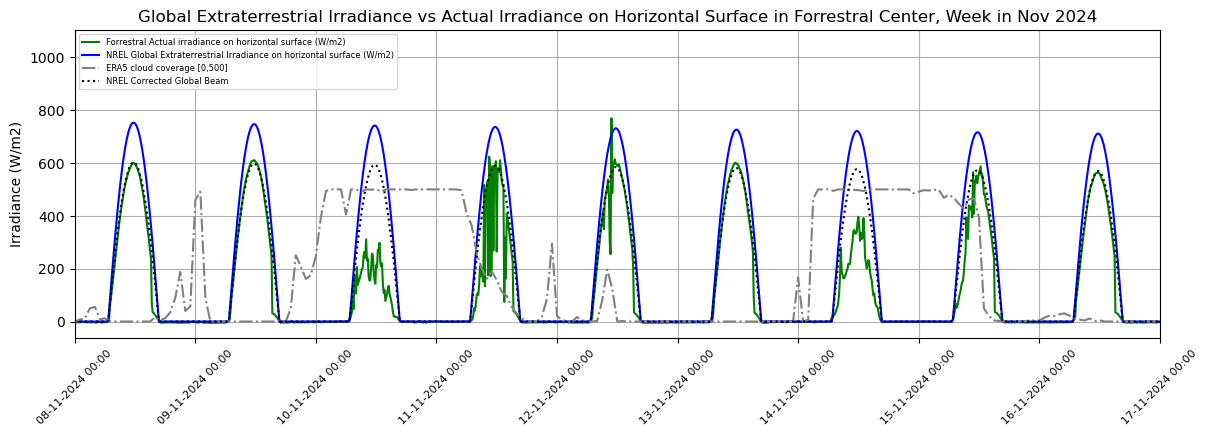

In [764]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(REAL_IRRADIANCE_post_nov.index, REAL_IRRADIANCE_post_nov['SW_up'], label = 'Forrestral Actual irradiance on horizontal surface (W/m2)', color = 'g')
ax.plot(DF_IRRADIANCE_forrestral.index, DF_IRRADIANCE_forrestral['GlobalIrradiance(W/m2)'], label = 'NREL Global Extraterrestrial Irradiance on horizontal surface (W/m2)', color = 'b') 
tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*500
ax.plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,500]', color = 'gray',linestyle = '-.') 
corected_ideal_global = DF_IRRADIANCE_forrestral['GlobalIrradiance(W/m2)']/1.25
ax.plot(corected_ideal_global.index, corected_ideal_global, label = 'NREL Corrected Global Beam', color = 'k',linestyle = ':') 

#ax.plot(merged_df.index, merged_df['dif_ideal_actual_ir'], label = 'Idea/actual clear days')

title = ('Global Extraterrestrial Irradiance vs Actual Irradiance on Horizontal Surface in Forrestral Center, Week in Nov 2024')

ax.set_title(title)
ax.legend(loc='upper left',fontsize = 6)

# Formatting x-axis for more frequent date ticks
#ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y %H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, size = 8)  # Rotate for readability
#plt.yticks(np.arange(0, 500, 1000))
#ax.set_yticks(np.arange(0, 1000, 50))

ax.grid()
ax.set_ylabel('Irradiance (W/m2)')
ax.set_xlim(pd.Timestamp('2024-11-08'), pd.Timestamp('2024-11-17'))
#plt.show()
plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution



## ambient temperature brice keegan 

In [1083]:
amb_temp_path = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/Data Brice Keegan/Ambient temperature"
amb_temp_wws = pd.read_csv(amb_temp_path +"/amb temp data WWS.csv")
amb_temp_wws.index = pd.to_datetime(amb_temp_wws.iloc[:,0])
amb_temp_TG_lot20 = pd.read_csv(amb_temp_path +"/amb temp data VP-WG-LG.csv")
amb_temp_TG_lot20.index = pd.to_datetime(amb_temp_TG_lot20.iloc[:,0])
#rename cols
amb_temp_TG_lot20 = amb_temp_TG_lot20.rename(columns ={'West Garage Weather Station 1 - Amb T; Mod T1; Wind: Ambient temp (TempF) Degrees Fahrenheit': 'TG_amb_temp_celsius',
                                             'Visitor Parking Weather Station 1 - Amb T; Mod T1; Wind: Ambient temp (TempF) Degrees Fahrenheit': 'Lot20_amb_temp_celsius'})

#change deg farenheit to celsius
amb_temp_wws.iloc[:,1] = deg_f_to_c(amb_temp_wws.iloc[:,1])
amb_temp_lot20 = deg_f_to_c(amb_temp_TG_lot20.iloc[:,1])
amb_temp_TG = deg_f_to_c(amb_temp_TG_lot20.iloc[:,2]) 
#rename cols
amb_temp_wws = amb_temp_wws.rename(columns={'Weather Station 1 - Amb T; Mod T1; Wind: Ambient temp (TempF) Degrees Fahrenheit': 'amb_temp_celsius'})

## Prepare dataframes for division -> make nubers <1 equal zero

In [766]:
DF_IRRADIANCE_forrestral.index

DatetimeIndex(['2024-11-03 00:00:00', '2024-11-03 00:10:00',
               '2024-11-03 00:20:00', '2024-11-03 00:30:00',
               '2024-11-03 00:40:00', '2024-11-03 00:50:00',
               '2024-11-03 01:00:00', '2024-11-03 01:10:00',
               '2024-11-03 01:20:00', '2024-11-03 01:30:00',
               ...
               '2025-02-27 22:20:00', '2025-02-27 22:30:00',
               '2025-02-27 22:40:00', '2025-02-27 22:50:00',
               '2025-02-27 23:00:00', '2025-02-27 23:10:00',
               '2025-02-27 23:20:00', '2025-02-27 23:30:00',
               '2025-02-27 23:40:00', '2025-02-27 23:50:00'],
              dtype='datetime64[ns]', name='Datetime', length=16848, freq=None)

In [767]:
REAL_IRRADIANCE_post_nov.loc[:,1] = REAL_IRRADIANCE_post_nov['SW_up'].where(REAL_IRRADIANCE_post_nov['SW_up'] >= 1, 0)
DF_IRRADIANCE_forrestral['GlobalIrradiance(W/m2)'] = DF_IRRADIANCE_forrestral['GlobalIrradiance(W/m2)'].where(DF_IRRADIANCE_forrestral['GlobalIrradiance(W/m2)'] >= 1, 0)

/var/folders/3l/cc81qd256klg0jhl1szlqmzw0000gn/T/ipykernel_94820/2935547102.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  REAL_IRRADIANCE_post_nov.loc[:,1] = REAL_IRRADIANCE_post_nov['SW_up'].where(REAL_IRRADIANCE_post_nov['SW_up'] >= 1, 0)


In [768]:
merged_df.index = pd.to_datetime(merged_df['key_0'])

fig, ax= plt.subplots(figsize = (14,4))
ax.plot(merged_df.index, merged_df['dif_ideal_actual_ir'])
title = ('Ideal:Actual Irradiance forrestral site on Horizontal Surface, Week in Nov 2024')

ax.set_title(title)
#ax.legend(loc='upper left',fontsize = 6)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
plt.xticks(rotation=30, size = 8)  # Rotate for readability
ax.grid()
ax.set_ylabel('Ideal/Actual')
ax.set_xlim(pd.Timestamp('2024-11-08'), pd.Timestamp('2024-11-16'))
ax.set_ylim(0,10)
ax.set_yticks(np.arange(0, 10.00, 0.5))
#plt.show()
graphs_path = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/graphs_jupyter_notebook"
plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution



NameError: name 'merged_df' is not defined

In [786]:
# difference between ideal an actual irradiance on clear days 
actual_ideal_ir_merged = pd.merge(DF_IRRADIANCE_forrestral, REAL_IRRADIANCE_post_nov, left_on=DF_IRRADIANCE_forrestral.index, right_on=REAL_IRRADIANCE_post_nov.index, how='inner')
#merged_df = DF_IRRADIANCE_forrestral_clear_days.join(REAL_IRRADIANCE_PRINCETON_10_min_clear_days, how='inner') 
#merged_df['dif_ideal_actual_ir'] = merged_df['GlobalIrradiance(W/m2)']/merged_df['SW_up']
actual_ideal_ir_merged.index = actual_ideal_ir_merged['key_0']

In [787]:
actual_ideal_ir_merged = actual_ideal_ir_merged.rename(columns={'SW_up': 'actual_ir_forrestral', 'GlobalIrradiance(W/m2)':'ideal_ir_solpos'})

In [788]:
actual_ideal_ir_merged['dif_actual_ideal'] =  actual_ideal_ir_merged['actual_ir_forrestral']/ (actual_ideal_ir_merged['ideal_ir_solpos'])
actual_ideal_ir_merged['dif_ideal_actual'] =  actual_ideal_ir_merged['ideal_ir_solpos']/ (actual_ideal_ir_merged['actual_ir_forrestral'])

#actual_ideal_ir_merged.loc[(actual_ideal_ir_merged['dif_ideal_actual'] > 10000) & (actual_ideal_ir_merged['actual_ir_forrestral'] > 100)]

### setting values where acutal ir > 0 and ideal ir = 0 to 0 (discarding infinity values) 

In [790]:
actual_ideal_ir_merged['dif_ideal_actual'] = actual_ideal_ir_merged['dif_ideal_actual'].where(actual_ideal_ir_merged['dif_ideal_actual'] < 100000, 0)
actual_ideal_ir_merged['dif_actual_ideal'] = actual_ideal_ir_merged['dif_actual_ideal'].where(actual_ideal_ir_merged['dif_actual_ideal'] < 100000, 0)
actual_ideal_ir_merged.fillna(0, inplace=True)
actual_ideal_ir_merged

,key_0,Datetime,ideal_ir_solpos,TIMESTAMP,actual_ir_forrestral,10_min_interval,1,dif_actual_ideal,dif_ideal_actual
key_0,,,,,,,,,
2024-11-03 00:00:00,2024-11-03 00:00:00,2024-11-03 00:00:00,0.0,2024-11-03 01:00:00,-2.887,True,0.0,-inf,-0.0
2024-11-03 00:10:00,2024-11-03 00:10:00,2024-11-03 00:10:00,0.0,2024-11-03 01:10:00,-1.887,True,0.0,-inf,-0.0
2024-11-03 00:20:00,2024-11-03 00:20:00,2024-11-03 00:20:00,0.0,2024-11-03 01:20:00,-1.771,True,0.0,-inf,-0.0
2024-11-03 00:30:00,2024-11-03 00:30:00,2024-11-03 00:30:00,0.0,2024-11-03 01:30:00,-2.079,True,0.0,-inf,-0.0
2024-11-03 00:40:00,2024-11-03 00:40:00,2024-11-03 00:40:00,0.0,2024-11-03 01:40:00,-1.887,True,0.0,-inf,-0.0
...,...,...,...,...,...,...,...,...,...
2025-02-27 23:10:00,2025-02-27 23:10:00,2025-02-27 23:10:00,0.0,2025-02-28 00:10:00,-3.811,True,0.0,-inf,-0.0
2025-02-27 23:20:00,2025-02-27 23:20:00,2025-02-27 23:20:00,0.0,2025-02-28 00:20:00,-4.042,True,0.0,-inf,-0.0
2025-02-27 23:30:00,2025-02-27 23:30:00,2025-02-27 23:30:00,0.0,2025-02-28 00:30:00,-3.926,True,0.0,-inf,-0.0


In [791]:
actual_ideal_ir_merged.loc[actual_ideal_ir_merged['dif_actual_ideal'] < 0] 

,key_0,Datetime,ideal_ir_solpos,TIMESTAMP,actual_ir_forrestral,10_min_interval,1,dif_actual_ideal,dif_ideal_actual
key_0,,,,,,,,,
2024-11-03 00:00:00,2024-11-03 00:00:00,2024-11-03 00:00:00,0.0,2024-11-03 01:00:00,-2.887,True,0.0,-inf,-0.0
2024-11-03 00:10:00,2024-11-03 00:10:00,2024-11-03 00:10:00,0.0,2024-11-03 01:10:00,-1.887,True,0.0,-inf,-0.0
2024-11-03 00:20:00,2024-11-03 00:20:00,2024-11-03 00:20:00,0.0,2024-11-03 01:20:00,-1.771,True,0.0,-inf,-0.0
2024-11-03 00:30:00,2024-11-03 00:30:00,2024-11-03 00:30:00,0.0,2024-11-03 01:30:00,-2.079,True,0.0,-inf,-0.0
2024-11-03 00:40:00,2024-11-03 00:40:00,2024-11-03 00:40:00,0.0,2024-11-03 01:40:00,-1.887,True,0.0,-inf,-0.0
...,...,...,...,...,...,...,...,...,...
2025-02-27 23:10:00,2025-02-27 23:10:00,2025-02-27 23:10:00,0.0,2025-02-28 00:10:00,-3.811,True,0.0,-inf,-0.0
2025-02-27 23:20:00,2025-02-27 23:20:00,2025-02-27 23:20:00,0.0,2025-02-28 00:20:00,-4.042,True,0.0,-inf,-0.0
2025-02-27 23:30:00,2025-02-27 23:30:00,2025-02-27 23:30:00,0.0,2025-02-28 00:30:00,-3.926,True,0.0,-inf,-0.0


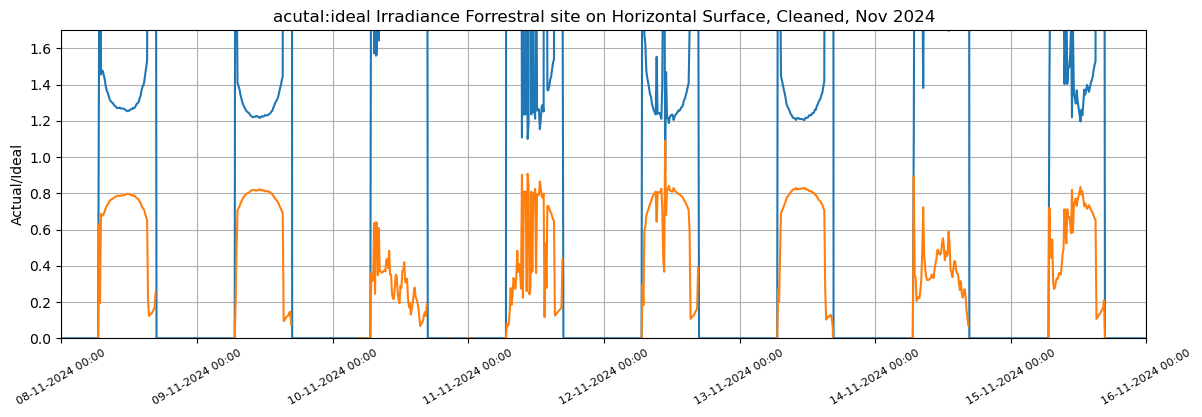

In [792]:
fig, ax= plt.subplots(figsize = (14,4))
ax.plot(actual_ideal_ir_merged.index, actual_ideal_ir_merged['dif_ideal_actual'], label = 'id/ac')
ax.plot(actual_ideal_ir_merged.index, actual_ideal_ir_merged['dif_actual_ideal'], label = 'actual/ideal')

title = ('acutal:ideal Irradiance Forrestral site on Horizontal Surface, Cleaned, Nov 2024')

ax.set_title(title)
#ax.legend(loc='upper left',fontsize = 6)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
plt.xticks(rotation=30, size = 8)  # Rotate for readability
ax.grid()
ax.set_ylabel('Actual/Ideal')
ax.set_xlim(pd.Timestamp('2024-11-08'), pd.Timestamp('2024-11-16'))
ax.set_ylim(0,1.7)
#ax.set_yticks(np.arange(0, 10.00, 0.5))
#plt.show()
graphs_path = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/graphs_jupyter_notebook"
plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution



In [793]:
# correcting the ideal horizontal beam of SOLPOS using Horizontal_actual/horizontal_ideal
SOLPOS_IRRADIANCE = DF_IRRADIANCE_forrestral
correcting_factor = actual_ideal_ir_merged['dif_actual_ideal']
global_ir_with_cf = pd.merge(correcting_factor, SOLPOS_IRRADIANCE, left_on=correcting_factor.index, right_on=SOLPOS_IRRADIANCE.index, how='inner')
global_ir_with_cf['corrected_beam'] = global_ir_with_cf['GlobalIrradiance(W/m2)']/global_ir_with_cf['dif_actual_ideal']
global_ir_with_cf['corrected_beam'] = global_ir_with_cf['corrected_beam'].where(global_ir_with_cf['corrected_beam'] < 10000, 0)
global_ir_with_cf.fillna(0, inplace=True)
global_ir_with_cf.loc[global_ir_with_cf['corrected_beam'] > 0]

,key_0,dif_actual_ideal,Datetime,GlobalIrradiance(W/m2),corrected_beam
40,2024-11-03 06:40:00,0.294409,2024-11-03 06:40:00,26.0284,88.408927
41,2024-11-03 06:50:00,0.478861,2024-11-03 06:50:00,66.0317,137.893277
42,2024-11-03 07:00:00,0.667895,2024-11-03 07:00:00,106.7233,159.790443
43,2024-11-03 07:10:00,0.658122,2024-11-03 07:10:00,147.3890,223.953787
44,2024-11-03 07:20:00,0.668376,2024-11-03 07:20:00,187.6189,280.708546
...,...,...,...,...,...
16787,2025-02-27 13:50:00,0.090987,2025-02-27 13:50:00,826.3805,9082.387695
16792,2025-02-27 14:40:00,0.075134,2025-02-27 14:40:00,709.2678,9440.060276
16800,2025-02-27 16:00:00,0.090456,2025-02-27 16:00:00,442.8682,4895.962121
16803,2025-02-27 16:30:00,0.064574,2025-02-27 16:30:00,323.5058,5009.861304


Locator attempting to generate 22174 ticks ([-1007.0, ..., 21166.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22174 ticks ([-1007.0, ..., 21166.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22174 ticks ([-1007.0, ..., 21166.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22174 ticks ([-1007.0, ..., 21166.0]), which exceeds Locator.MAXTICKS (1000).


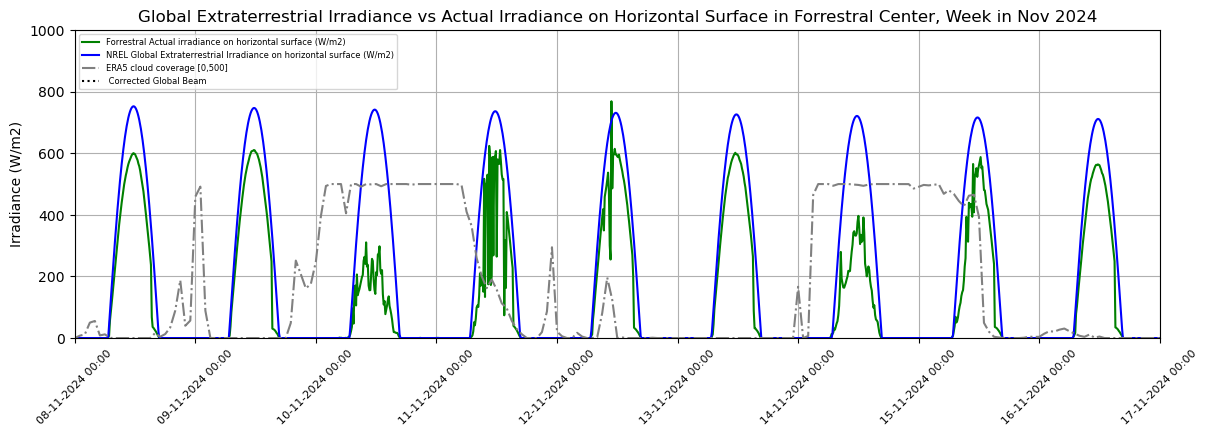

In [794]:
#Plotting corrected irradiance 

# merge the correcting factor (actual/ horizontal) and apply to the ideal beam
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(REAL_IRRADIANCE_post_nov.index, REAL_IRRADIANCE_post_nov['SW_up'], label = 'Forrestral Actual irradiance on horizontal surface (W/m2)', color = 'g')
ax.plot(DF_IRRADIANCE_forrestral.index, DF_IRRADIANCE_forrestral['GlobalIrradiance(W/m2)'], label = 'NREL Global Extraterrestrial Irradiance on horizontal surface (W/m2)', color = 'b') 
tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*500
ax.plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,500]', color = 'gray',linestyle = '-.') 
ax.plot(global_ir_with_cf.index, global_ir_with_cf['corrected_beam'], label = ' Corrected Global Beam', color = 'k',linestyle = ':') 

#ax.plot(merged_df.index, merged_df['dif_ideal_actual_ir'], label = 'Idea/actual clear days')

title = ('Global Extraterrestrial Irradiance vs Actual Irradiance on Horizontal Surface in Forrestral Center, Week in Nov 2024')

ax.set_title(title)
ax.legend(loc='upper left',fontsize = 6)

# Formatting x-axis for more frequent date ticks
#ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y %H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, size = 8)  # Rotate for readability
#plt.yticks(np.arange(0, 500, 1000))
#ax.set_yticks(np.arange(0, 1000, 50))
ax.set_ylim(0,1000)

ax.grid()
ax.set_ylabel('Irradiance (W/m2)')
ax.set_xlim(pd.Timestamp('2024-11-08'), pd.Timestamp('2024-11-17'))
#plt.show()
plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution




## Plotting SOLPOS horiztonal global beam irradiance with correction factor

### creating the correction factor: Horizontal_actual/horizontal Ideal

In [797]:
ax.plot(REAL_IRRADIANCE_post_nov.index, REAL_IRRADIANCE_post_nov['SW_up'], label = 'Forrestral Actual irradiance on horizontal surface (W/m2)', color = 'g')
ax.plot(DF_IRRADIANCE_forrestral.index, DF_IRRADIANCE_forrestral['GlobalIrradiance(W/m2)'], label = 'NREL Global Extraterrestrial Irradiance on horizontal surface (W/m2)', color = 'b') 
tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*500

REAL_IRRADIANCE_post_nov
SOLPOS_H_irradiance = DF_IRRADIANCE_forrestral #rename for convenience
ideal_and_actual_H_irr = pd.merge(SOLPOS_H_irradiance['GlobalIrradiance(W/m2)'], REAL_IRRADIANCE_post_nov['SW_up'], left_on=SOLPOS_H_irradiance.index, right_on=REAL_IRRADIANCE_post_nov.index, how='inner')

ideal_and_actual_H_irr['correction_factor'] = ideal_and_actual_H_irr['SW_up']/ideal_and_actual_H_irr['GlobalIrradiance(W/m2)']
# clean correction factor from NaN and infinity 
ideal_and_actual_H_irr.fillna(0, inplace=True)
ideal_and_actual_H_irr['correction_factor'].replace([np.inf, -np.inf], 0.0, inplace=True)
ideal_and_actual_H_irr.index = pd.to_datetime(ideal_and_actual_H_irr['key_0'])

/var/folders/3l/cc81qd256klg0jhl1szlqmzw0000gn/T/ipykernel_94820/1151019830.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ideal_and_actual_H_irr['correction_factor'].replace([np.inf, -np.inf], 0.0, inplace=True)


In [798]:
# merge the SOLPOS horzontal ideal with the correction factor 
SOLPOS_ideal_with_correction = pd.merge(SOLPOS_H_irradiance['GlobalIrradiance(W/m2)'], ideal_and_actual_H_irr['correction_factor'], left_on=SOLPOS_H_irradiance.index, right_on=ideal_and_actual_H_irr.index, how='inner')
SOLPOS_ideal_with_correction.index = pd.to_datetime(SOLPOS_ideal_with_correction['key_0'])
# multiply the global irradiance by the correction factor 
SOLPOS_ideal_with_correction['corrected_ideal_beam'] = SOLPOS_ideal_with_correction['GlobalIrradiance(W/m2)']*SOLPOS_ideal_with_correction['correction_factor']


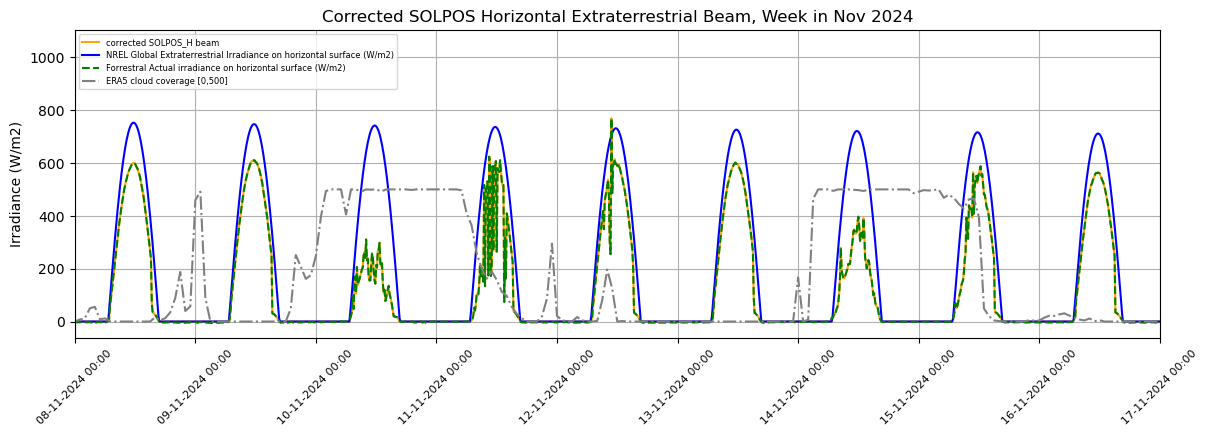

In [799]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(SOLPOS_ideal_with_correction.index, SOLPOS_ideal_with_correction['corrected_ideal_beam'], label = 'corrected SOLPOS_H beam', color = 'orange')
#ax.plot(REAL_IRRADIANCE_post_nov.index, REAL_IRRADIANCE_post_nov['SW_up'], label = 'Forrestral Actual irradiance on horizontal surface (W/m2)', color = 'g')
ax.plot(DF_IRRADIANCE_forrestral.index, DF_IRRADIANCE_forrestral['GlobalIrradiance(W/m2)'], label = 'NREL Global Extraterrestrial Irradiance on horizontal surface (W/m2)', color = 'b') 
ax.plot(REAL_IRRADIANCE_post_nov.index, REAL_IRRADIANCE_post_nov['SW_up'], label = 'Forrestral Actual irradiance on horizontal surface (W/m2)', color = 'g', linestyle = '--')

tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*500
ax.plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,500]', color = 'gray',linestyle = '-.') 
title = ('Corrected SOLPOS Horizontal Extraterrestrial Beam, Week in Nov 2024')

ax.set_title(title)
ax.legend(loc='upper left',fontsize = 6)

# Formatting x-axis for more frequent date ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y %H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, size = 8)  # Rotate for readability
ax.grid()
ax.set_ylabel('Irradiance (W/m2)')
ax.set_xlim(pd.Timestamp('2024-11-08'), pd.Timestamp('2024-11-17'))
#plt.show()
plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution



## Plot the actual out irradiance for each titled surface on clear days

In [801]:
CF = ideal_and_actual_H_irr['correction_factor']

In [945]:
DF_IRRADIANCE_WWS2 = DF_IRRADIANCE_WWS002
DF_IRRADIANCE_WWS3 = DF_IRRADIANCE_WWS002 # the ideal beam model hitting WWS3 stage is identical to that of WWS2
DF_IRRADIANCE_PRS3 = DF_IRRADIANCE_PRS003
DF_IRRADIANCE_PRS5 = DF_IRRADIANCE_PRS005
DF_IRRADIANCE_WWS002.index = DF_IRRADIANCE_WWS002.iloc[:,0] 
DF_IRRADIANCE_PRS003.index = DF_IRRADIANCE_PRS003.iloc[:,0] 
DF_IRRADIANCE_PRS005_160.index = DF_IRRADIANCE_PRS005_160.iloc[:,0] 
DF_IRRADIANCE_PRS005_340.index = DF_IRRADIANCE_PRS005_340.iloc[:,0] 


# POINTER1
# merge all df with correction factor 
WWS2_tilted_actual_ir = pd.merge(DF_IRRADIANCE_WWS2, CF, left_on = DF_IRRADIANCE_WWS2.index, right_on = CF.index, how = 'inner') 
WWS3_tilted_actual_ir = pd.merge(DF_IRRADIANCE_WWS3, CF, left_on = DF_IRRADIANCE_WWS3.index, right_on = CF.index, how = 'inner') 
PRS3_tilted_actual_ir = pd.merge(DF_IRRADIANCE_PRS3, CF, left_on = DF_IRRADIANCE_PRS3.index, right_on = CF.index, how = 'inner') 


PRS5_tilted_actual_160_ir = pd.merge(DF_IRRADIANCE_PRS005_160, CF, left_on = DF_IRRADIANCE_PRS005_160.index, right_on = CF.index, how = 'inner') 
PRS5_tilted_actual_340_ir = pd.merge(DF_IRRADIANCE_PRS005_340, CF, left_on = DF_IRRADIANCE_PRS005_340.index, right_on = CF.index, how = 'inner') 


WWS2_tilted_actual_ir.index = WWS2_tilted_actual_ir.iloc[:,0]
WWS3_tilted_actual_ir.index = WWS3_tilted_actual_ir.iloc[:,0]
PRS3_tilted_actual_ir.index = PRS3_tilted_actual_ir.iloc[:,0]

PRS5_tilted_actual_160_ir.index = PRS5_tilted_actual_160_ir.iloc[:,0]
PRS5_tilted_actual_340_ir.index = PRS5_tilted_actual_340_ir.iloc[:,0]

WWS2_tilted_actual_ir['corrected_beam'] = WWS2_tilted_actual_ir['GlobalIrradiance(W/m2)'] * WWS2_tilted_actual_ir['correction_factor']
WWS3_tilted_actual_ir['corrected_beam'] = WWS3_tilted_actual_ir['GlobalIrradiance(W/m2)'] * WWS3_tilted_actual_ir['correction_factor']
PRS3_tilted_actual_ir['corrected_beam'] = PRS3_tilted_actual_ir['GlobalIrradiance(W/m2)'] * PRS3_tilted_actual_ir['correction_factor']
PRS5_tilted_actual_160_ir['corrected_beam'] = PRS5_tilted_actual_160_ir['GlobalIrradiance(W/m2)'] * PRS5_tilted_actual_160_ir['correction_factor']
PRS5_tilted_actual_340_ir['corrected_beam'] = PRS5_tilted_actual_340_ir['GlobalIrradiance(W/m2)'] * PRS5_tilted_actual_340_ir['correction_factor']



In [803]:
'''
#fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(WWS2_tilted_actual_ir.index, WWS2_tilted_actual_ir['corrected_beam'], label = 'WWS2 Corected Tilted beam', color = 'g')
#ax.plot(WWS3_tilted_actual_ir.index, WWS3_tilted_actual_ir['corrected_beam'], label = 'WWS3 Corected Tilted beam', color = 'y')
#ax.plot(PRS3_tilted_actual_ir.index, PRS3_tilted_actual_ir['corrected_beam'], label = 'PRS3 Corected Tilted beam', color = 'r')
#ax.plot(PRS5_tilted_actual_ir.index, PRS5_tilted_actual_ir['corrected_beam'], label = 'PRS5 Corected Tilted beam', color = 'b')

#ax.plot(WWS2_tilted_actual_ir.index, WWS2_tilted_actual_ir['GlobalIrradiance(W/m2)'], label = 'WWS2/WWS3 Ideal Tilted beam', color = 'gray')
#ax.plot(PRS3_tilted_actual_ir.index, PRS3_tilted_actual_ir['GlobalIrradiance(W/m2)'], label = 'PRS3 Ideal Tilted beam', color = 'k')

tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*500
ax.plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,500]', color = 'gray',linestyle = '-.') 
title = ('Corrected Irradiance on Tilted Modules in all Fields, Two Weeks in Nov 2024')

ax.set_title(title)
ax.legend(loc='upper left',fontsize = 6)

# Formatting x-axis for more frequent date ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y %H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, size = 8)  # Rotate for readability
ax.grid()
ax.set_ylabel('Irradiance (W/m2)')
ax.set_xlim(pd.Timestamp('2024-11-15'), pd.Timestamp('2024-11-20'))
ax.set_ylim(0,1000)
#plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution
'''

'\n#fig, ax = plt.subplots(figsize=(14, 4))\n\nax.plot(WWS2_tilted_actual_ir.index, WWS2_tilted_actual_ir[\'corrected_beam\'], label = \'WWS2 Corected Tilted beam\', color = \'g\')\n#ax.plot(WWS3_tilted_actual_ir.index, WWS3_tilted_actual_ir[\'corrected_beam\'], label = \'WWS3 Corected Tilted beam\', color = \'y\')\n#ax.plot(PRS3_tilted_actual_ir.index, PRS3_tilted_actual_ir[\'corrected_beam\'], label = \'PRS3 Corected Tilted beam\', color = \'r\')\n#ax.plot(PRS5_tilted_actual_ir.index, PRS5_tilted_actual_ir[\'corrected_beam\'], label = \'PRS5 Corected Tilted beam\', color = \'b\')\n\n#ax.plot(WWS2_tilted_actual_ir.index, WWS2_tilted_actual_ir[\'GlobalIrradiance(W/m2)\'], label = \'WWS2/WWS3 Ideal Tilted beam\', color = \'gray\')\n#ax.plot(PRS3_tilted_actual_ir.index, PRS3_tilted_actual_ir[\'GlobalIrradiance(W/m2)\'], label = \'PRS3 Ideal Tilted beam\', color = \'k\')\n\ntcc_0_500 = ERA5_CLIMATE_DATA[\'tcc\']*500\nax.plot(tcc_0_500.index, tcc_0_500, label = \'ERA5 cloud coverage [0,500

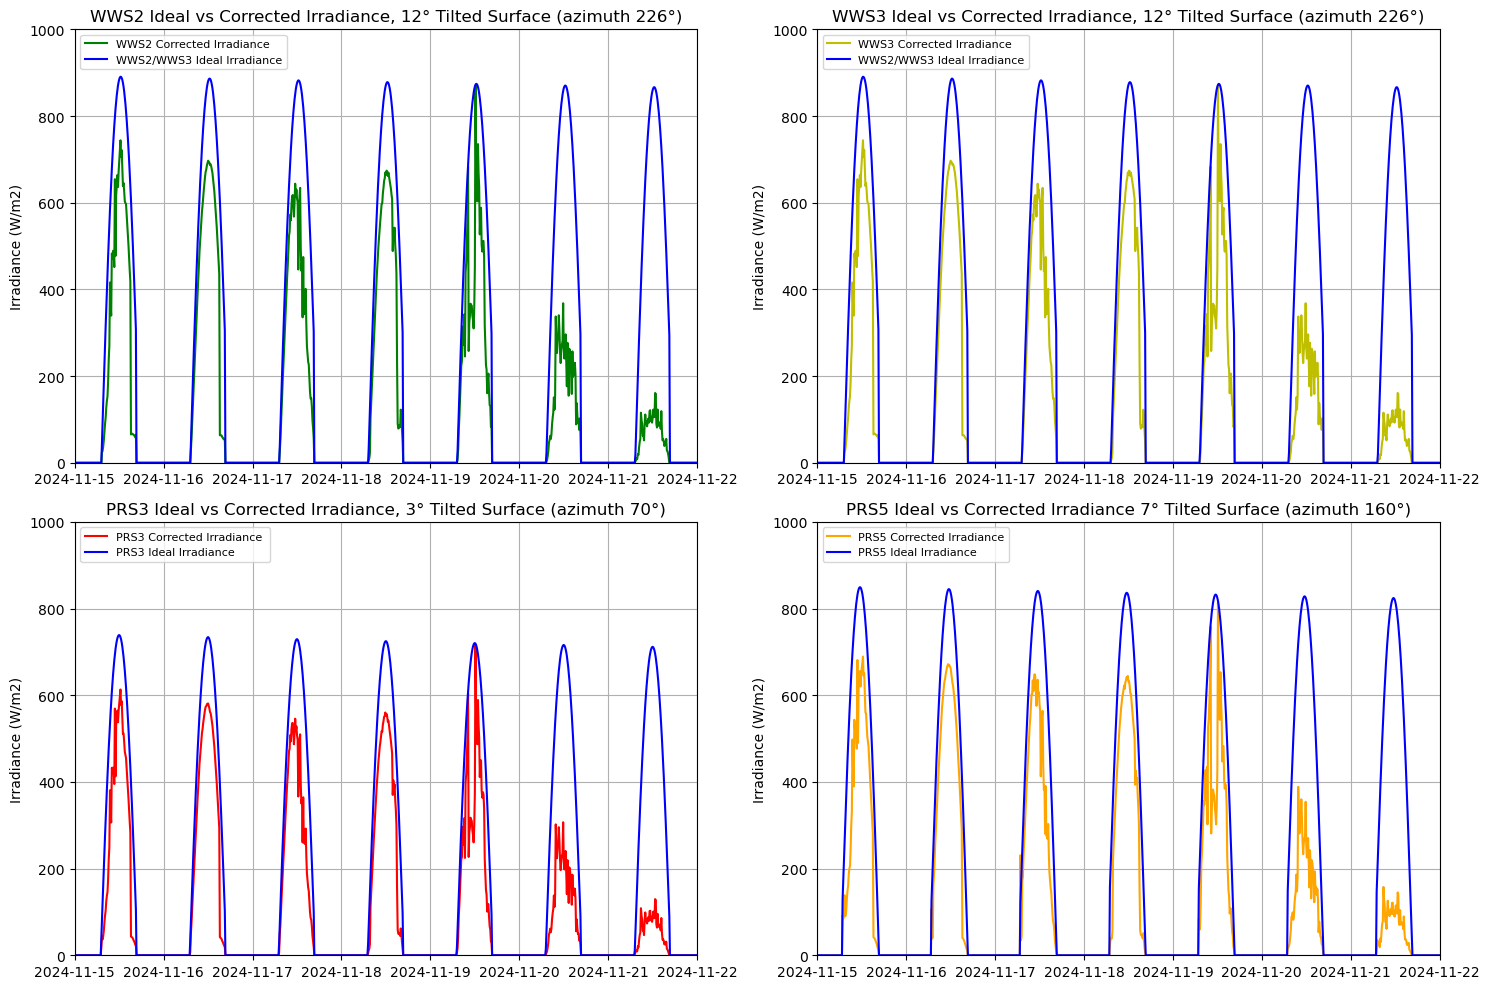

In [947]:
# plot the ideal and corrected beam for each field

fig, axs = plt.subplots(2, 2)
axs[0, 0].plot(WWS2_tilted_actual_ir.index, WWS2_tilted_actual_ir['corrected_beam'], label = 'WWS2 Corrected Irradiance', color = 'g')
axs[0, 0].plot(WWS2_tilted_actual_ir.index, WWS2_tilted_actual_ir['GlobalIrradiance(W/m2)'], label = 'WWS2/WWS3 Ideal Irradiance', color = 'b')

axs[0, 1].plot(WWS3_tilted_actual_ir.index, WWS3_tilted_actual_ir['corrected_beam'], label = 'WWS3 Corrected Irradiance', color = 'y')
axs[0, 1].plot(WWS3_tilted_actual_ir.index, WWS3_tilted_actual_ir['GlobalIrradiance(W/m2)'], label = 'WWS2/WWS3 Ideal Irradiance', color = 'b')

axs[1, 0].plot(PRS3_tilted_actual_ir.index, PRS3_tilted_actual_ir['corrected_beam'], label = 'PRS3 Corrected Irradiance ', color = 'r')
axs[1, 0].plot(PRS3_tilted_actual_ir.index, PRS3_tilted_actual_ir['GlobalIrradiance(W/m2)'], label = 'PRS3 Ideal Irradiance', color = 'b')

axs[1, 1].plot(PRS5_tilted_actual_160_ir.index, PRS5_tilted_actual_160_ir['corrected_beam'], label = 'PRS5 Corrected Irradiance', color = 'orange')
axs[1, 1].plot(PRS5_tilted_actual_160_ir.index, PRS5_tilted_actual_160_ir['GlobalIrradiance(W/m2)'], label = 'PRS5 Ideal Irradiance', color = 'b')

#tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*500
#ax.plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,500]', color = 'gray',linestyle = '-.') 

axs[0,0].set_title("WWS2 Ideal vs Corrected Irradiance, 12° Tilted Surface (azimuth 226°)")
axs[0,1].set_title("WWS3 Ideal vs Corrected Irradiance, 12° Tilted Surface (azimuth 226°)")
axs[1,0].set_title("PRS3 Ideal vs Corrected Irradiance, 3° Tilted Surface (azimuth 70°)")
axs[1,1].set_title("PRS5 Ideal vs Corrected Irradiance 7° Tilted Surface (azimuth 160°)")

axs[0,0].legend(loc = 'upper left', fontsize = 8)
axs[0,1].legend(loc = 'upper left', fontsize = 8)
axs[1,0].legend(loc = 'upper left', fontsize = 8)
axs[1,1].legend(loc = 'upper left', fontsize = 8)

axs[0,0].set_xlim(pd.Timestamp('2024-11-15'), pd.Timestamp('2024-11-22'))
axs[0,1].set_xlim(pd.Timestamp('2024-11-15'), pd.Timestamp('2024-11-22'))
axs[1,0].set_xlim(pd.Timestamp('2024-11-15'), pd.Timestamp('2024-11-22'))
axs[1,1].set_xlim(pd.Timestamp('2024-11-15'), pd.Timestamp('2024-11-22'))

axs[0,0].set_ylim(0,1000)
axs[0,1].set_ylim(0,1000)
axs[1,0].set_ylim(0,1000)
axs[1,1].set_ylim(0,1000)

axs[0,0].grid()
axs[0,1].grid()
axs[1,0].grid()
axs[1,1].grid()


axs[0,0].set_ylabel('Irradiance (W/m2)')
axs[0,1].set_ylabel('Irradiance (W/m2)')
axs[1,0].set_ylabel('Irradiance (W/m2)')
axs[1,1].set_ylabel('Irradiance (W/m2)')



fig.set_size_inches(15,10)
plt.tight_layout()

title = "Corrected and Ideal Tilted Beams in all Fields, Two Weeks in Nov 2024"
plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution


## Model the power out of each field

## import temperature data to model power out 

In [807]:
# sensor temperature data from Brice K using a BAPI temperature logger (data for WWS002/003 not available)
path_BAPI_temp_data = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/Data Brice Keegan/Module Temperature/Module Temp Data VP-WG-LG.csv"
BAPI_temp_data = pd.read_csv(path_BAPI_temp_data)
BAPI_temp_PRS005 = BAPI_temp_data.iloc[:,[0,1]]
BAPI_temp_PRS005.loc[:,"temp_celsius"] = deg_f_to_c(BAPI_temp_PRS005.iloc[:,1])
BAPI_temp_PRS005.index = pd.to_datetime(BAPI_temp_PRS005.iloc[:,0])
BAPI_temp_PRS003 = BAPI_temp_data.iloc[:,[0,2]]
BAPI_temp_PRS003.loc[:,"temp_celsius"] = deg_f_to_c(BAPI_temp_PRS003.iloc[:,1])
BAPI_temp_PRS003.index = pd.to_datetime(BAPI_temp_PRS003.iloc[:,0])

/var/folders/3l/cc81qd256klg0jhl1szlqmzw0000gn/T/ipykernel_94820/3994670577.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BAPI_temp_PRS005.loc[:,"temp_celsius"] = deg_f_to_c(BAPI_temp_PRS005.iloc[:,1])
/var/folders/3l/cc81qd256klg0jhl1szlqmzw0000gn/T/ipykernel_94820/3994670577.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BAPI_temp_PRS003.loc[:,"temp_celsius"] = deg_f_to_c(BAPI_temp_PRS003.iloc[:,1])


In [808]:
wws2_path = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/Parsed (clean) on-field data/WWS002.xlsx"
wws3_path = "/Users/danielavita/Documents/Princeton/academic year 2024-2025/Fall 2024-2025/ECE Senior Thesis/Parsed (clean) on-field data/WWS003.xlsx"

wws2_module_temp = pd.read_excel(wws2_path, sheet_name="iButton module temperature")
wws3_module_temp = pd.read_excel(wws3_path, sheet_name = "iButton module temperature")

# pad empty dates where data was not collected with NaN
wws2_module_temp.index = wws2_module_temp.iloc[:,0]
wws3_module_temp.index = wws3_module_temp.iloc[:,0] 

# set sepearte df for each sensor, choosing the sensors that logged most accurately.
wws2_sensor12 = pad_empty_dates(wws2_module_temp.loc[wws2_module_temp['sensor number'] == 12])
wws3_sensor9 = pad_empty_dates(wws3_module_temp.loc[wws3_module_temp['sensor number'] == 9])

In [949]:
# module power out TG and Lot20
# merge tmperature with irradiance dataframe
PRS3_tilted_actual_ir = PRS3_tilted_actual_ir.rename(columns={'key_0':'time'})
PRS5_tilted_actual_160_ir = PRS5_tilted_actual_160_ir.rename(columns={'key_0':'time'})
PRS5_tilted_actual_340_ir = PRS5_tilted_actual_340_ir.rename(columns={'key_0':'time'})

PRS3_ir_with_temp = pd.merge(PRS3_tilted_actual_ir, BAPI_temp_PRS003, left_on = PRS3_tilted_actual_ir.index, right_on = BAPI_temp_PRS003.index, how ='inner')
PRS5_ir_160_with_temp = pd.merge(PRS5_tilted_actual_160_ir, BAPI_temp_PRS005, left_on = PRS5_tilted_actual_160_ir.index, right_on = BAPI_temp_PRS005.index, how ='inner')
PRS5_ir_340_with_temp = pd.merge(PRS5_tilted_actual_340_ir, BAPI_temp_PRS005, left_on = PRS5_tilted_actual_340_ir.index, right_on = BAPI_temp_PRS005.index, how ='inner')

PRS3_ir_with_temp.index = pd.to_datetime(PRS3_ir_with_temp.iloc[:,0])
PRS5_ir_160_with_temp.index = pd.to_datetime(PRS5_ir_160_with_temp.iloc[:,0])
PRS5_ir_340_with_temp.index = pd.to_datetime(PRS5_ir_340_with_temp.iloc[:,0])


In [967]:
PRS3_ir_with_temp['modeled_p_out'] = module_power_out_kw_series(PRS3_ir_with_temp['temp_celsius'], PRS3_ir_with_temp['corrected_beam'], PRS003)
PRS5_ir_160_with_temp['half_modeled_p_out_160'] = module_power_out_kw_series(PRS5_ir_160_with_temp['temp_celsius'], PRS5_ir_160_with_temp['corrected_beam'], PRS005)
PRS5_ir_340_with_temp['half_modeled_p_out_340'] = module_power_out_kw_series(PRS5_ir_340_with_temp['temp_celsius'], PRS5_ir_340_with_temp['corrected_beam'], PRS005)
#POINTER1
#PRS5_ir_with_temp['modeled_p_out'] = module_power_out_kw_series(PRS5_ir_with_temp['temp_celsius'], PRS5_ir_with_temp['corrected_beam'], PRS005)
PRS5_ir_with_temp = pd.merge(PRS5_ir_160_with_temp, PRS5_ir_340_with_temp, right_on = PRS5_ir_160_with_temp.index, left_on = PRS5_ir_340_with_temp.index, how ='inner')

PRS5_ir_with_temp.index = pd.to_datetime(PRS5_ir_with_temp.iloc[:,0])
# taking under account the V shape of PRS5 lot20 
PRS5_ir_with_temp['modeled_p_out'] = 0.5*PRS5_ir_with_temp['half_modeled_p_out_160'] + 0.5*PRS5_ir_340_with_temp['half_modeled_p_out_340']
PRS5_ir_with_temp

,key_0,key_0_x,time_x,Datetime_x,GlobalIrradiance(W/m2)_x,correction_factor_x,corrected_beam_x,Site Time_x,"Visitor Parking Weather Station 2 - GHI; Mod T2, Module temp Degrees Fahrenheit_x",temp_celsius_x,...,Datetime_y,GlobalIrradiance(W/m2)_y,correction_factor_y,corrected_beam_y,Site Time_y,"Visitor Parking Weather Station 2 - GHI; Mod T2, Module temp Degrees Fahrenheit_y",temp_celsius_y,modeled_p_out_y,half_modeled_p_out_340,modeled_p_out
key_0,,,,,,,,,,,,,,,,,,,,,
2024-11-15 00:00:00,2024-11-15 00:00:00,2024-11-15 00:00:00,2024-11-15 00:00:00,2024-11-15 00:00:00,0.0,0.0,0.0,11-15-2024 00:00:00,40.726,4.847778,...,2024-11-15 00:00:00,0.0,0.0,0.0,11-15-2024 00:00:00,40.726,4.847778,0.0,0.0,0.0
2024-11-15 01:00:00,2024-11-15 01:00:00,2024-11-15 01:00:00,2024-11-15 01:00:00,2024-11-15 01:00:00,0.0,0.0,0.0,11-15-2024 01:00:00,41.038,5.021111,...,2024-11-15 01:00:00,0.0,0.0,0.0,11-15-2024 01:00:00,41.038,5.021111,0.0,0.0,0.0
2024-11-15 02:00:00,2024-11-15 02:00:00,2024-11-15 02:00:00,2024-11-15 02:00:00,2024-11-15 02:00:00,0.0,0.0,0.0,11-15-2024 02:00:00,40.687,4.826111,...,2024-11-15 02:00:00,0.0,0.0,0.0,11-15-2024 02:00:00,40.687,4.826111,0.0,0.0,0.0
2024-11-15 03:00:00,2024-11-15 03:00:00,2024-11-15 03:00:00,2024-11-15 03:00:00,2024-11-15 03:00:00,0.0,0.0,0.0,11-15-2024 03:00:00,40.146,4.525556,...,2024-11-15 03:00:00,0.0,0.0,0.0,11-15-2024 03:00:00,40.146,4.525556,0.0,0.0,0.0
2024-11-15 04:00:00,2024-11-15 04:00:00,2024-11-15 04:00:00,2024-11-15 04:00:00,2024-11-15 04:00:00,0.0,0.0,0.0,11-15-2024 04:00:00,39.823,4.346111,...,2024-11-15 04:00:00,0.0,0.0,0.0,11-15-2024 04:00:00,39.823,4.346111,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-27 19:00:00,2025-02-27 19:00:00,2025-02-27 19:00:00,2025-02-27 19:00:00,2025-02-27 19:00:00,0.0,0.0,0.0,02-27-2025 19:00:00,47.302,8.501111,...,2025-02-27 19:00:00,0.0,0.0,0.0,02-27-2025 19:00:00,47.302,8.501111,0.0,0.0,0.0
2025-02-27 20:00:00,2025-02-27 20:00:00,2025-02-27 20:00:00,2025-02-27 20:00:00,2025-02-27 20:00:00,0.0,0.0,0.0,02-27-2025 20:00:00,49.400,9.666667,...,2025-02-27 20:00:00,0.0,0.0,0.0,02-27-2025 20:00:00,49.400,9.666667,0.0,0.0,0.0
2025-02-27 21:00:00,2025-02-27 21:00:00,2025-02-27 21:00:00,2025-02-27 21:00:00,2025-02-27 21:00:00,0.0,0.0,0.0,02-27-2025 21:00:00,46.488,8.048889,...,2025-02-27 21:00:00,0.0,0.0,0.0,02-27-2025 21:00:00,46.488,8.048889,0.0,0.0,0.0


(0.0, 700.0)

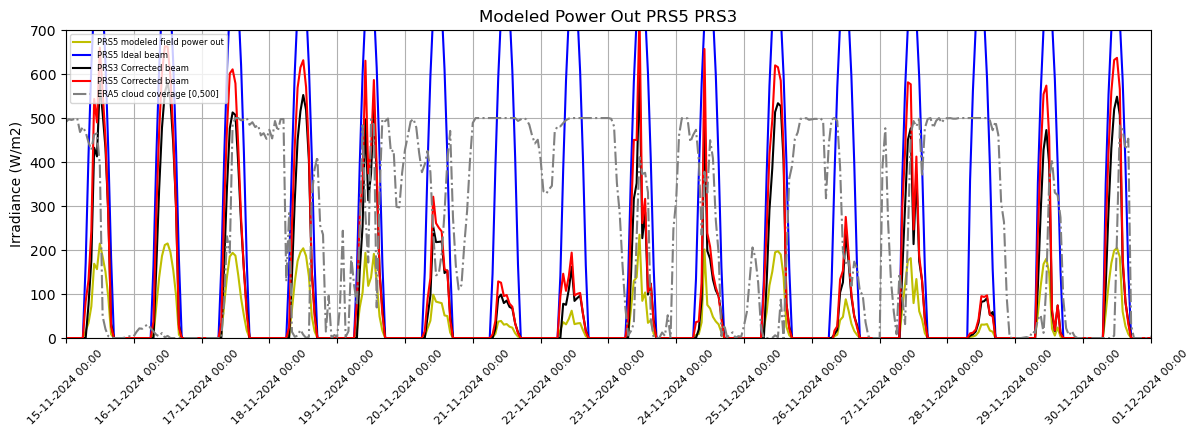

In [1041]:

fig, ax = plt.subplots(figsize=(14, 4))

PRS3_num_modules = 2144
PRS5_num_modules = 6032

#ax.plot(PRS3_ir_with_temp.index, PRS3_ir_with_temp['modeled_p_out'], label = 'PRS3 module field power out', color = 'g')
ax.plot(PRS5_ir_with_temp.index, PRS5_ir_with_temp['modeled_p_out'], label = 'PRS5 modeled field power out', color = 'y')
ax.plot(PRS5_ir_with_temp.index, PRS5_ir_with_temp['GlobalIrradiance(W/m2)_x'], label = 'PRS5 Ideal beam', color = 'b')

#ax.plot(PRS5_ir_with_temp.index, PRS5_ir_with_temp['temp_celsius'], label = 'PRS5 temp', color = 'r')
#ax.plot(PRS3_ir_with_temp.index, PRS3_ir_with_temp['temp_celsius'], label = 'PRS3 temp', color = 'b')
ax.plot(PRS3_ir_with_temp.index, PRS3_ir_with_temp['corrected_beam'], label = 'PRS3 Corrected beam', color = 'k')
ax.plot(PRS5_ir_with_temp.index, PRS5_ir_with_temp['corrected_beam_x'], label = 'PRS5 Corrected beam', color = 'r')

tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*500
ax.plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,500]', color = 'gray',linestyle = '-.') 
title = ('Modeled Power Out PRS5 PRS3')

ax.set_title(title)
ax.legend(loc='upper left',fontsize = 6)

# Formatting x-axis for more frequent date ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y %H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.tick_params(axis='x', labelrotation=45, labelsize=8)

ax.grid()
ax.set_ylabel('Irradiance (W/m2)')
ax.set_xlim(pd.Timestamp('2024-11-15'), pd.Timestamp('2024-12-01'))
ax.set_ylim(0,700)
#plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution


In [832]:
WWS2_tilted_actual_ir = WWS2_tilted_actual_ir.rename(columns={'key_0':'time'})
WWS3_tilted_actual_ir = WWS3_tilted_actual_ir.rename(columns={'key_0':'time'})

WWS2_ir_with_temp = pd.merge(WWS2_tilted_actual_ir, wws2_sensor12['Value (C)'], left_on = WWS2_tilted_actual_ir.index, right_on = wws2_sensor12.index, how ='right')
WWS3_ir_with_temp = pd.merge(WWS3_tilted_actual_ir, wws3_sensor9['Value'], left_on = WWS2_tilted_actual_ir.index, right_on = wws3_sensor9.index, how ='right')

'''
# remove the rows where there is no temperature value logged
WWS2_ir_with_temp = WWS2_ir_with_temp[WWS2_ir_with_temp['Value (C)'].notna()]
'''
WWS2_ir_with_temp['modeled_p_out'] = module_power_out_kw_series(WWS2_ir_with_temp['Value (C)'], WWS2_ir_with_temp['corrected_beam'], WWS002)
WWS3_ir_with_temp['modeled_p_out'] = module_power_out_kw_series(WWS3_ir_with_temp['Value'], WWS3_ir_with_temp['corrected_beam'], WWS003)
WWS2_ir_with_temp.index = pd.to_datetime(WWS2_ir_with_temp.iloc[:,0])
WWS3_ir_with_temp.index = pd.to_datetime(WWS3_ir_with_temp.iloc[:,0])


(0.0, 700.0)

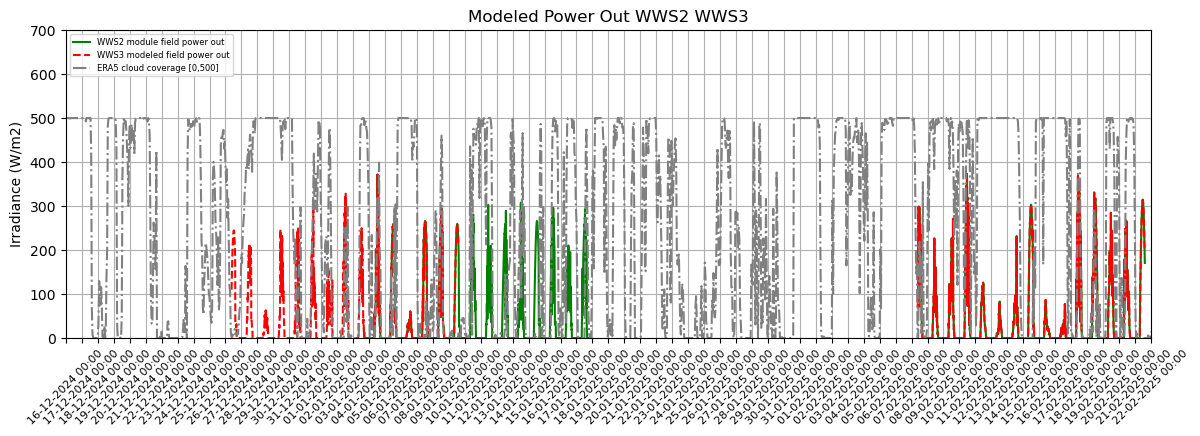

In [834]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(WWS2_ir_with_temp.index, WWS2_ir_with_temp['modeled_p_out'], label = 'WWS2 module field power out', color = 'g')
ax.plot(WWS3_ir_with_temp.index, WWS3_ir_with_temp['modeled_p_out'], label = 'WWS3 modeled field power out', color = 'r',linestyle = '--')

tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*500
ax.plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,500]', color = 'gray',linestyle = '-.') 
title = ('Modeled Power Out WWS2 WWS3')

ax.set_title(title)
ax.legend(loc='upper left',fontsize = 6)

# Formatting x-axis for more frequent date ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y %H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, size = 8)  # Rotate for readability
ax.grid()
ax.set_ylabel('Irradiance (W/m2)')
ax.set_xlim(pd.Timestamp('2024-12-16'), pd.Timestamp('2025-02-22'))
ax.set_ylim(0,700)


In [836]:
CF[30:50]

key_0
2024-11-03 05:00:00    0.000000
2024-11-03 05:10:00    0.000000
2024-11-03 05:20:00    0.000000
2024-11-03 05:30:00    0.000000
2024-11-03 05:40:00    0.000000
2024-11-03 05:50:00    0.000000
2024-11-03 06:00:00    0.000000
2024-11-03 06:10:00    0.000000
2024-11-03 06:20:00    0.000000
2024-11-03 06:30:00    0.000000
2024-11-03 06:40:00    0.294409
2024-11-03 06:50:00    0.478861
2024-11-03 07:00:00    0.667895
2024-11-03 07:10:00    0.658122
2024-11-03 07:20:00    0.668376
2024-11-03 07:30:00    0.692313
2024-11-03 07:40:00    0.713476
2024-11-03 07:50:00    0.723488
2024-11-03 08:00:00    0.737785
2024-11-03 08:10:00    0.755920
Name: correction_factor, dtype: float64

In [837]:
#add actual power out per module into plot 
wws002_num_modules = WWS002.field_capacity / WWS002.module_capacity[0]
wws003_num_modules = WWS003.field_capacity / WWS003.module_capacity[0]
prs003_num_modules = PRS003.field_capacity / PRS003.module_capacity[0]
prs005_num_modules = PRS005.field_capacity/ PRS005.module_capacity[0]

wws2_avg_module_p_W= (DF_REAL_POWER_WWS002.iloc[:,1] /wws002_num_modules) *1000
wws3_avg_module_p_W = (DF_REAL_POWER_WWS003.iloc[:,1] /wws003_num_modules) *1000
prs3_avg_module_p_W = (DF_REAL_POWER_PRS003.iloc[:,1] /prs003_num_modules) *1000
prs5_avg_module_p_W = (DF_REAL_POWER_PRS005.iloc[:,1] /prs005_num_modules) *1000

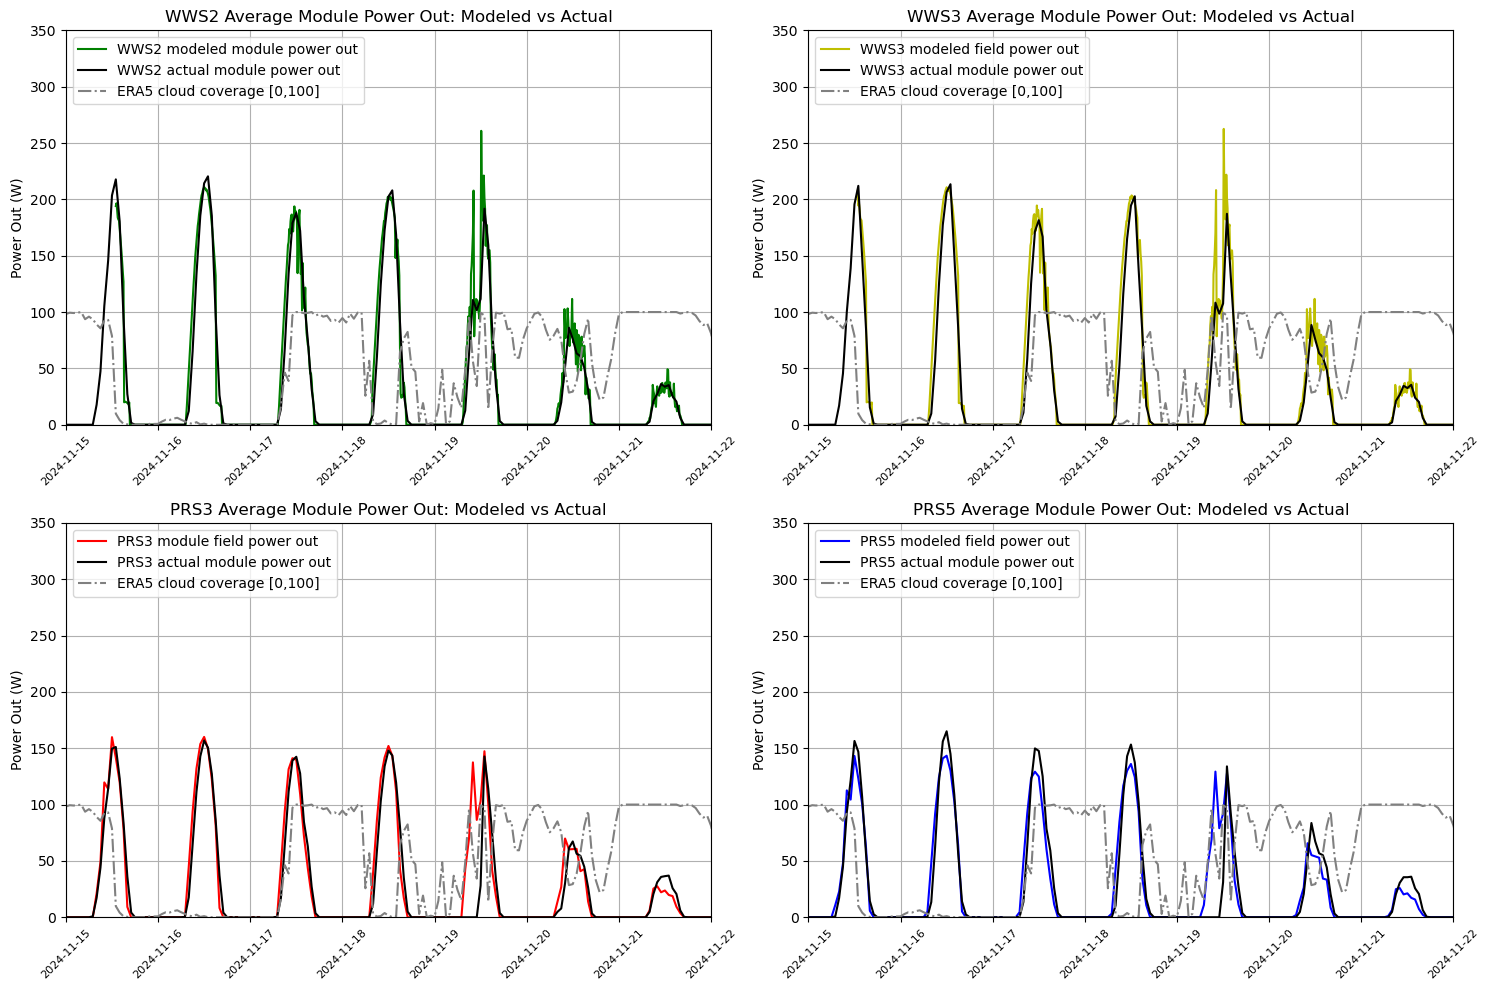

In [1043]:
#plot the difference between modeled power out and real power out for each field 
fig, axs = plt.subplots(2, 2)
axs_flat = axs.flatten()

tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*100

axs[0,0].plot(WWS2_ir_with_temp.index, WWS2_ir_with_temp['modeled_p_out']/1.25, label = 'WWS2 modeled module power out', color = 'g')
axs[0,0].plot(wws2_avg_module_p_W.index, wws2_avg_module_p_W, label = 'WWS2 actual module power out', color = 'k')
axs[0,0].set_title("WWS2 Average Module Power Out: Modeled vs Actual")
axs[0,0].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-.') 

axs[0,1].plot(WWS3_ir_with_temp.index, WWS3_ir_with_temp['modeled_p_out']/1.25, label = 'WWS3 modeled field power out', color = 'y',linestyle = '-')
axs[0,1].plot(wws3_avg_module_p_W.index, wws3_avg_module_p_W, label = 'WWS3 actual module power out', color = 'k')
axs[0,1].set_title("WWS3 Average Module Power Out: Modeled vs Actual")
axs[0,1].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-.') 


axs[1,0].plot(PRS3_ir_with_temp.index, PRS3_ir_with_temp['modeled_p_out']/1.4, label = 'PRS3 module field power out', color = 'r')
axs[1,0].plot(prs3_avg_module_p_W.index, prs3_avg_module_p_W, label = 'PRS3 actual module power out', color = 'k')
axs[1,0].set_title("PRS3 Average Module Power Out: Modeled vs Actual")
axs[1,0].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-.') 

axs[1,1].plot(PRS5_ir_with_temp.index, PRS5_ir_with_temp['modeled_p_out']/1.5, label = 'PRS5 modeled field power out', color = 'b')
axs[1,1].plot(prs5_avg_module_p_W.index, prs5_avg_module_p_W, label = 'PRS5 actual module power out', color = 'k')
axs[1,1].set_title("PRS5 Average Module Power Out: Modeled vs Actual")
axs[1,1].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-.') 

axs[0,0].set_xlim(pd.Timestamp('2024-11-15'), pd.Timestamp('2024-11-22'))
axs[0,1].set_xlim(pd.Timestamp('2024-11-15'), pd.Timestamp('2024-11-22'))
axs[1,0].set_xlim(pd.Timestamp('2024-11-15'), pd.Timestamp('2024-11-22'))
axs[1,1].set_xlim(pd.Timestamp('2024-11-15'), pd.Timestamp('2024-11-22'))

axs[0,0].set_ylim(0,350)
axs[0,1].set_ylim(0,350)
axs[1,0].set_ylim(0,350)
axs[1,1].set_ylim(0,350)

axs[0,0].legend(loc = 'upper left')
axs[0,1].legend(loc = 'upper left')
axs[1,0].legend(loc = 'upper left')
axs[1,1].legend(loc = 'upper left')

axs[0,1].set_ylim(0,350)
axs[1,0].set_ylim(0,350)
axs[0,1].set_ylim(0,350)
axs[1,1].set_ylim(0,350)

axs[0,0].grid()
axs[0,1].grid()
axs[1,0].grid()
axs[1,1].grid()

plt.xticks(rotation=45, size = 8)  # Rotate for readability

axs[0,0].set_ylabel("Power Out (W)")
axs[0,1].set_ylabel("Power Out (W)")
axs[1,0].set_ylabel("Power Out (W)")
axs[1,1].set_ylabel("Power Out (W)")

axs[0,0].tick_params(axis='x', labelrotation=45, labelsize=8)
axs[0,1].tick_params(axis='x', labelrotation=45, labelsize=8)
axs[1,0].tick_params(axis='x', labelrotation=45, labelsize=8)
axs[1,1].tick_params(axis='x', labelrotation=45, labelsize=8)

fig.set_size_inches(15,10)
plt.tight_layout()
title = "Average Modeled Power Out vs Average Actual Power Out per Module in all Fields"
plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution



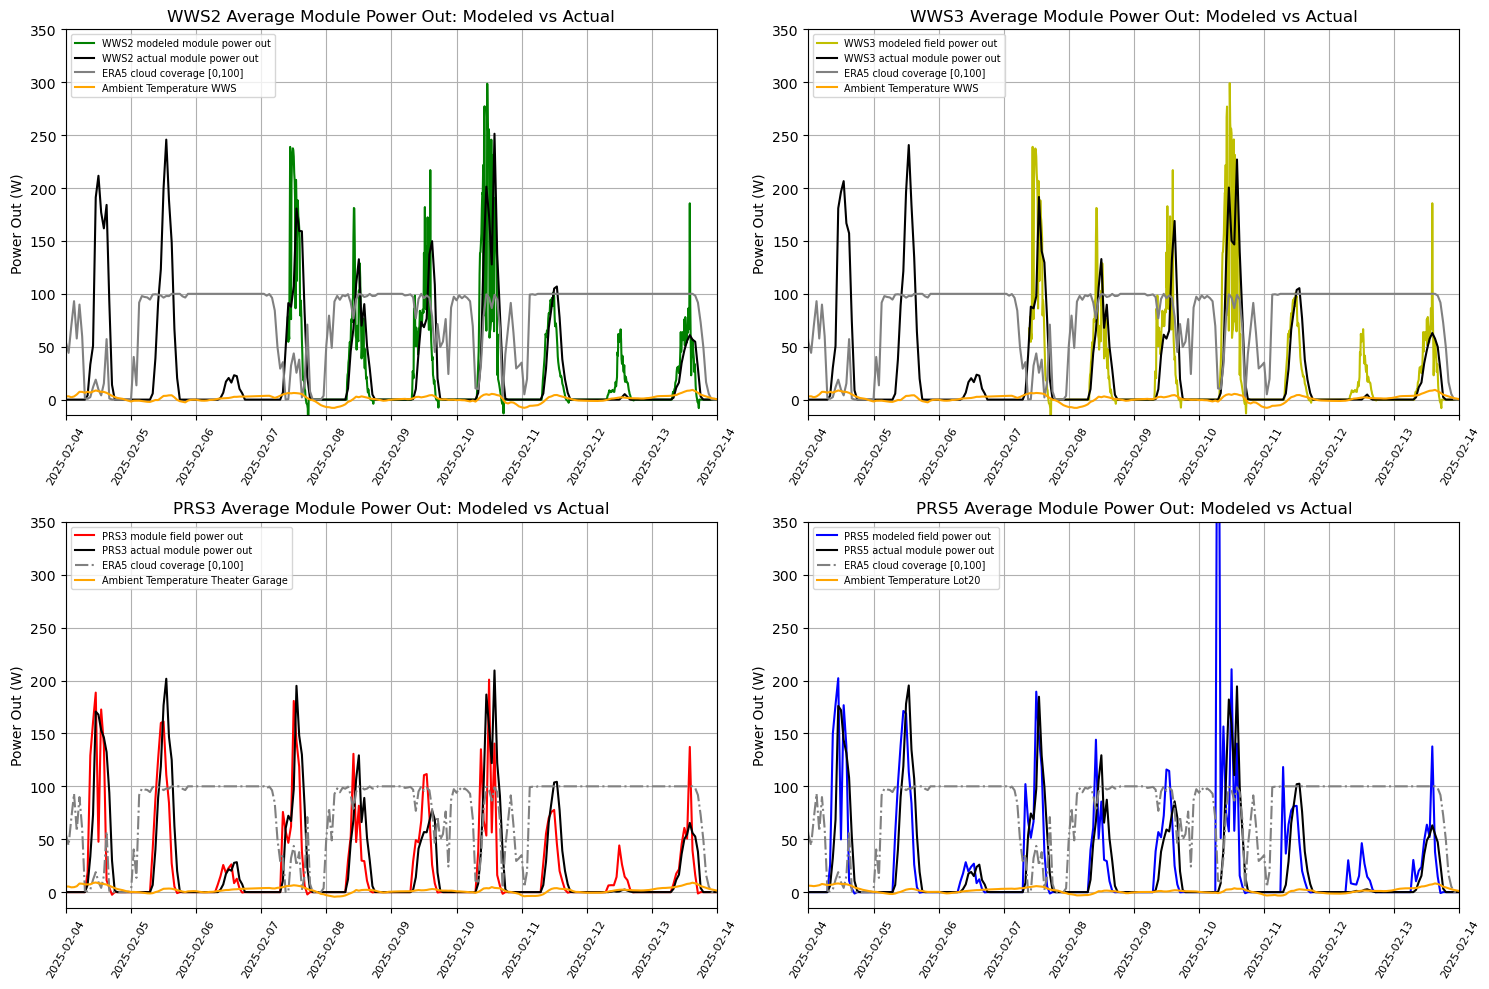

In [1127]:
#plot the difference between modeled power out and real power out for each field 
fig, axs = plt.subplots(2, 2)
axs_flat = axs.flatten()

tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*100

axs[0,0].plot(WWS2_ir_with_temp.index, WWS2_ir_with_temp['modeled_p_out']/1.25, label = 'WWS2 modeled module power out', color = 'g')
axs[0,0].plot(wws2_avg_module_p_W.index, wws2_avg_module_p_W, label = 'WWS2 actual module power out', color = 'k')
axs[0,0].set_title("WWS2 Average Module Power Out: Modeled vs Actual")
axs[0,0].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-') 
axs[0,0].plot(amb_temp_wws.index, amb_temp_wws.iloc[:,1], label = 'Ambient Temperature WWS', color = 'orange', linestyle = '-')

axs[0,1].plot(WWS3_ir_with_temp.index, WWS3_ir_with_temp['modeled_p_out']/1.25, label = 'WWS3 modeled field power out', color = 'y',linestyle = '-')
axs[0,1].plot(wws3_avg_module_p_W.index, wws3_avg_module_p_W, label = 'WWS3 actual module power out', color = 'k')
axs[0,1].set_title("WWS3 Average Module Power Out: Modeled vs Actual")
axs[0,1].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-') 
axs[0,1].plot(amb_temp_wws.index, amb_temp_wws.iloc[:,1], label = 'Ambient Temperature WWS', color = 'orange', linestyle = '-')


axs[1,0].plot(PRS3_ir_with_temp.index, PRS3_ir_with_temp['modeled_p_out']/1.4, label = 'PRS3 module field power out', color = 'r')
axs[1,0].plot(prs3_avg_module_p_W.index, prs3_avg_module_p_W, label = 'PRS3 actual module power out', color = 'k')
axs[1,0].set_title("PRS3 Average Module Power Out: Modeled vs Actual")
axs[1,0].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-.') 
axs[1,0].plot(amb_temp_TG.index, amb_temp_TG, label = 'Ambient Temperature Theater Garage', color = 'orange', linestyle = '-')

axs[1,1].plot(PRS5_ir_with_temp.index, PRS5_ir_with_temp['modeled_p_out']/1.3, label = 'PRS5 modeled field power out', color = 'b')
axs[1,1].plot(prs5_avg_module_p_W.index, prs5_avg_module_p_W, label = 'PRS5 actual module power out', color = 'k')
axs[1,1].set_title("PRS5 Average Module Power Out: Modeled vs Actual")
axs[1,1].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-.') 
axs[1,1].plot(amb_temp_lot20.index, amb_temp_lot20, label = 'Ambient Temperature Lot20', color = 'orange', linestyle = '-')

axs[0,0].set_xlim(pd.Timestamp('2025-02-4'), pd.Timestamp('2025-02-14'))
axs[0,1].set_xlim(pd.Timestamp('2025-02-4'), pd.Timestamp('2025-02-14'))
axs[1,0].set_xlim(pd.Timestamp('2025-02-4'), pd.Timestamp('2025-02-14'))
axs[1,1].set_xlim(pd.Timestamp('2025-02-4'), pd.Timestamp('2025-02-14'))

axs[0,0].legend(loc = 'upper left', fontsize = 7)
axs[0,1].legend(loc = 'upper left', fontsize = 7)
axs[1,0].legend(loc = 'upper left', fontsize = 7)
axs[1,1].legend(loc = 'upper left', fontsize = 7)


axs[0,0].grid()
axs[0,1].grid()
axs[1,0].grid()
axs[1,1].grid()

axs[0,0].tick_params(axis='x', labelrotation=60, labelsize=8)
axs[0,1].tick_params(axis='x', labelrotation=60, labelsize=8)
axs[1,0].tick_params(axis='x', labelrotation=60, labelsize=8)
axs[1,1].tick_params(axis='x', labelrotation=60, labelsize=8)

axs[0,0].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs[1,0].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs[0,1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs[1,1].xaxis.set_major_locator(mdates.DayLocator(interval=1))

axs[0,0].set_ylabel("Power Out (W)")
axs[0,1].set_ylabel("Power Out (W)")
axs[1,0].set_ylabel("Power Out (W)")
axs[1,1].set_ylabel("Power Out (W)")

axs[0,0].set_ylim(-15,350)
axs[1,0].set_ylim(-15,350)
axs[0,1].set_ylim(-15,350)
axs[1,1].set_ylim(-15,350)

fig.set_size_inches(15,10)
plt.tight_layout()
title = "Average Modeled Power Out vs Average Actual Power Out per Module in all Fields with temp Feb 25'"
plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution



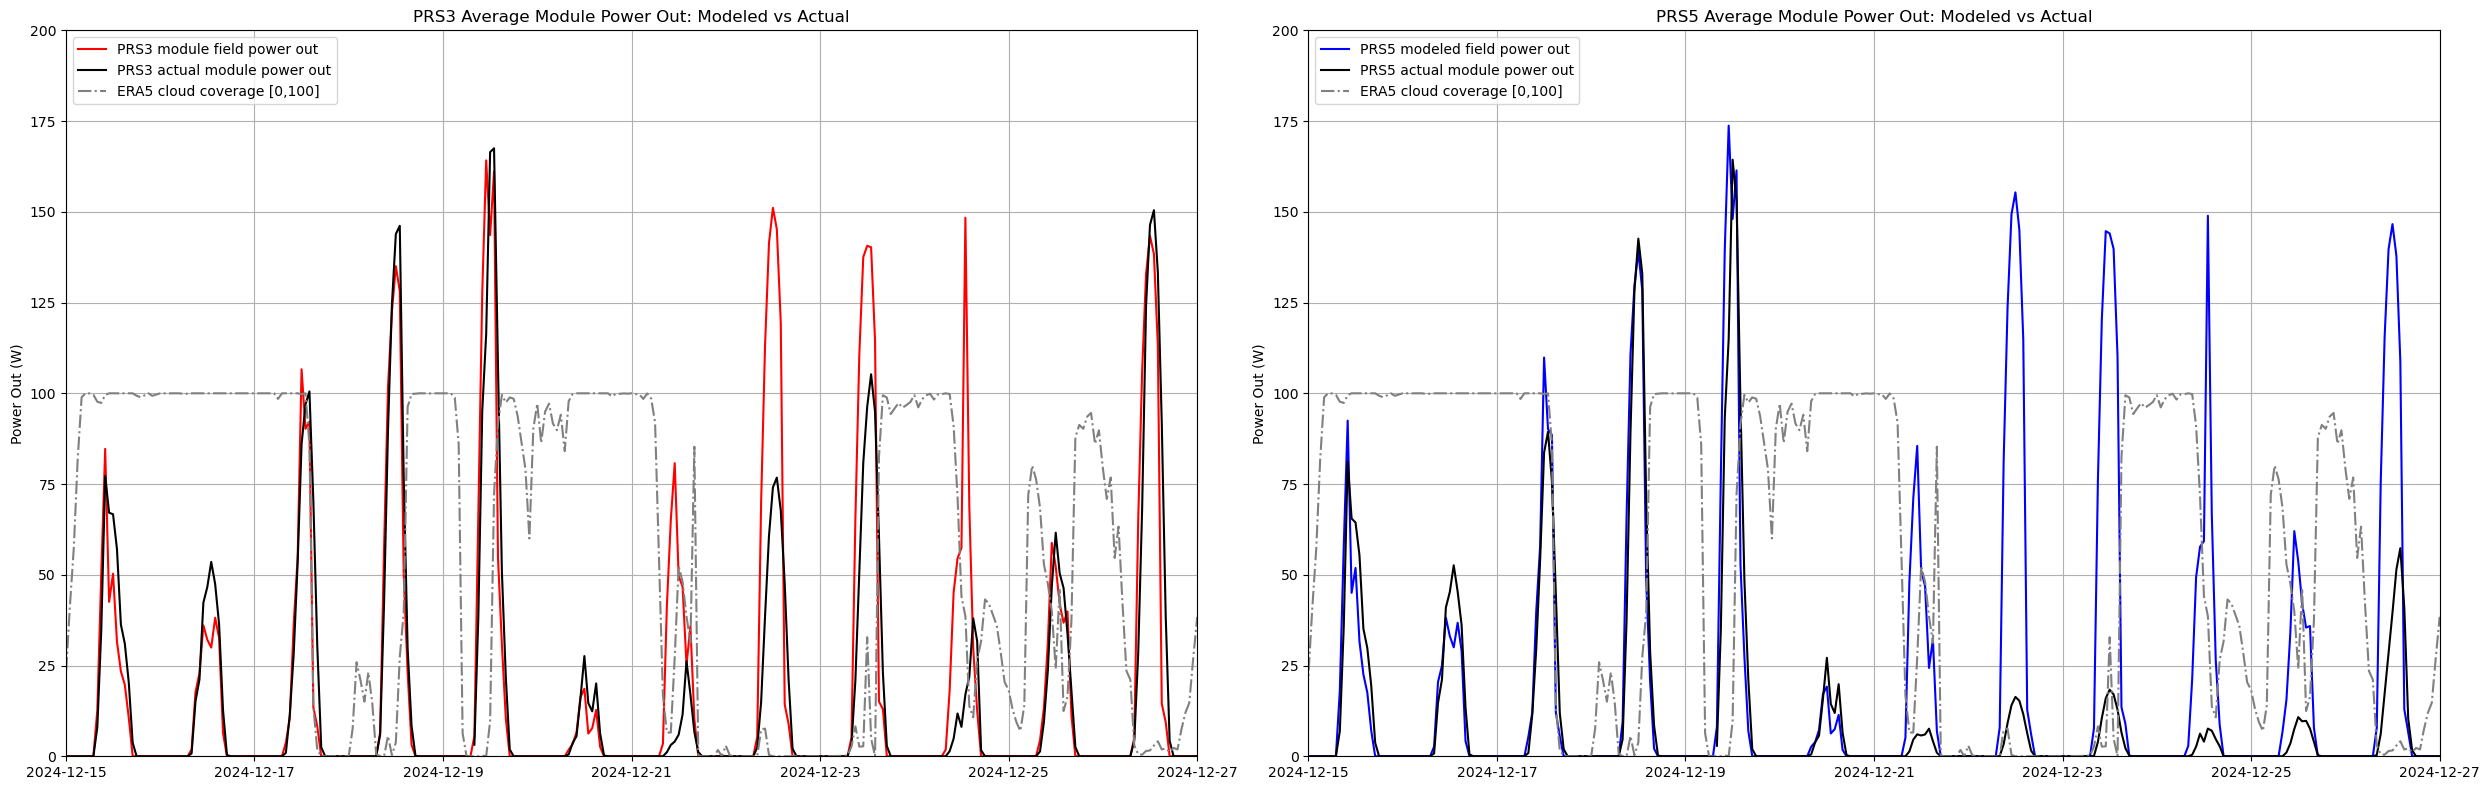

In [1011]:
#plotting only PRS3 and PRS5 on dates where there in no temperature data for WWS 
fig, axs = plt.subplots(1, 2)
axs_flat = axs.flatten()

tcc_0_500 = ERA5_CLIMATE_DATA['tcc']*100
'''
axs[0,0].plot(WWS2_ir_with_temp.index, WWS2_ir_with_temp['modeled_p_out']/1.25, label = 'WWS2 modeled module power out', color = 'g')
axs[0,0].plot(wws2_avg_module_p_W.index, wws2_avg_module_p_W, label = 'WWS2 actual module power out', color = 'k')
axs[0,0].set_title("WWS2 Average Module Power Out: Modeled vs Actual")
axs[0,0].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-.') 

axs[0,1].plot(WWS3_ir_with_temp.index, WWS3_ir_with_temp['modeled_p_out']/1.25, label = 'WWS3 modeled field power out', color = 'y',linestyle = '-')
axs[0,1].plot(wws3_avg_module_p_W.index, wws3_avg_module_p_W, label = 'WWS3 actual module power out', color = 'k')
axs[0,1].set_title("WWS3 Average Module Power Out: Modeled vs Actual")
axs[0,1].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-.') 
'''
axs[0].plot(PRS3_ir_with_temp.index, PRS3_ir_with_temp['modeled_p_out']/1.4, label = 'PRS3 module field power out', color = 'r')
axs[0].plot(prs3_avg_module_p_W.index, prs3_avg_module_p_W, label = 'PRS3 actual module power out', color = 'k')
axs[0].set_title("PRS3 Average Module Power Out: Modeled vs Actual")
axs[0].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-.') 

axs[1].plot(PRS5_ir_with_temp.index, PRS5_ir_with_temp['modeled_p_out']/1.3, label = 'PRS5 modeled field power out', color = 'b')
axs[1].plot(prs5_avg_module_p_W.index, prs5_avg_module_p_W, label = 'PRS5 actual module power out', color = 'k')
axs[1].set_title("PRS5 Average Module Power Out: Modeled vs Actual")
axs[1].plot(tcc_0_500.index, tcc_0_500, label = 'ERA5 cloud coverage [0,100]', color = 'gray',linestyle = '-.') 

axs[0].set_xlim(pd.Timestamp('2025-01-01'), pd.Timestamp('2024-12-27'))
axs[1].set_xlim(pd.Timestamp('2025-01-15'), pd.Timestamp('2024-12-27'))

axs[0].set_ylim(0,350)
axs[1].set_ylim(0,350)

axs[0].legend(loc = 'upper left')
axs[1].legend(loc = 'upper left')

axs[1].set_ylim(0,200)
axs[0].set_ylim(0,200)

axs[0].grid()
axs[1].grid()

axs[0].set_ylabel("Power Out (W)")
axs[1].set_ylabel("Power Out (W)")

fig.set_size_inches(25,8)
plt.tight_layout()
title = "Average Modeled Power Out vs Average Actual Power Out per Module Lot20 and TG end of Dec'"
plt.savefig(graphs_path + "/" + title, dpi=600, bbox_inches="tight")  # Save at high resolution


In [1081]:
ERA5_CLIMATE_DATA

,latitude,longitude,t2m,tcc,date
time,,,,,
2023-12-31 19:00:00,40.2,-74.7,4.867340,0.832673,2023-12-31 19:00:00
2023-12-31 20:00:00,40.2,-74.7,4.534821,0.914246,2023-12-31 20:00:00
2023-12-31 21:00:00,40.2,-74.7,4.079010,0.847622,2023-12-31 21:00:00
2023-12-31 22:00:00,40.2,-74.7,4.167389,0.699265,2023-12-31 22:00:00
2023-12-31 23:00:00,40.2,-74.7,4.354401,0.871769,2023-12-31 23:00:00
...,...,...,...,...,...
2025-02-28 14:00:00,40.2,-74.7,10.883453,0.559662,2025-02-28 14:00:00
2025-02-28 15:00:00,40.2,-74.7,10.917877,0.855501,2025-02-28 15:00:00
2025-02-28 16:00:00,40.2,-74.7,10.781158,0.605058,2025-02-28 16:00:00


In [1099]:
amb_temp_wws

,Site Time,amb_temp_celsius
Site Time,,
2024-11-15 00:00:00,11-15-2024 00:00:00,5.163333
2024-11-15 01:00:00,11-15-2024 01:00:00,5.258333
2024-11-15 02:00:00,11-15-2024 02:00:00,5.337778
2024-11-15 03:00:00,11-15-2024 03:00:00,5.100556
2024-11-15 04:00:00,11-15-2024 04:00:00,4.983333
...,...,...
2025-03-25 19:00:00,03-25-2025 19:00:00,NaN
2025-03-25 20:00:00,03-25-2025 20:00:00,NaN
2025-03-25 21:00:00,03-25-2025 21:00:00,NaN
